In [1]:
import os
import argparse
import numpy as np
import pandas as pd
from decimal import *
import matplotlib.pyplot as plt
from tqdm import tqdm

In [20]:
def update_delta(gamma_j, beta):
    return 1/gamma_j * ((gamma_j*(beta - 1) + 1)**(1/(1 - beta)))

def update_eff(n_a, E_o, S_o, delta_e, k_C, n_d):
    # if E_o - n_a* S_o is positive, the exponential value of this expression will explode in calculation.
    # The original form of efficiency formula contains negative exponent and
    # the simplified form contains the positive exponent
    
    if (E_o - n_a*S_o) >= 0:
        return n_d * (n_a - \
                        ((E_o - n_a*S_o)*n_a*np.exp(-(E_o - n_a * S_o) * k_C * delta_e))/ \
                        (E_o - n_a*S_o*np.exp(-(E_o - n_a*S_o) * k_C * delta_e)))
    else:
        return n_d * (n_a - \
                    ((E_o - n_a*S_o) * n_a)/ \
                        (E_o * np.exp((E_o - n_a * S_o) * k_C * delta_e) - n_a * S_o))
    
def simulate_vals(D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=50):
    S_o, gamma, delta, n_a, eff = [], [], [], [], []
    P_o, E_o, D_e = [P_init], [E_init], [D_init]

    n_cycle = int(n_cycle)
    # print(n_cycle)

    for i in range(n_cycle):
        S_o_j = n_d*D_e[i]
        S_o.append(S_o_j)

        gamma_j = S_o_j/(P_o[i] + Decimal(1e-200))
        gamma.append(gamma_j)
        
        # print(gamma_j)

        delta_j = update_delta(gamma_j, beta=beta)
        delta.append(delta_j)

        n_a_j = 1/gamma_j - delta_j
        n_a.append(n_a_j)

        E_o_j = (n_dE**(i+1)) * E_o[0]
        E_o.append(E_o_j)

        eff_j = update_eff(n_a=n_a_j, E_o=E_o_j, S_o=S_o_j, delta_e=delta_e, k_C=k_C, n_d=n_d)
        eff.append(eff_j)
        # print('At cycle {}, PCR efficiency is {}'.format(i, eff_j))

        D_e_j = (eff_j + 1)*D_e[i]
        D_e.append(D_e_j)

        P_o_j = P_o[i] - eff_j * S_o_j
        P_o.append(P_o_j)
    
    return eff, n_a, D_e, S_o, E_o, P_o, gamma, delta

In [3]:
# define constants
k_C = Decimal(15)
n_d = Decimal(1)
n_dE = Decimal(0.99)

beta = Decimal(25)

delta_e = Decimal(100)

In [32]:
# Generating synthetic curve for comparison
D_init = Decimal(1000)
P_init = Decimal(9.e5)
E_init = Decimal(1e5)

D_e = simulate_vals(D_init=D_init,
                        E_init=E_init, 
                        P_init=P_init, 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=44)[2]

D_e = np.array([float(str(x)) for x in D_e])


# Reading in initial curve for comparison
known_df = pd.read_csv('./data/known_dilution_multicomponent.csv')
known_df.head(2)
curve = known_df.loc[(known_df.loc[:,'Well Position'] == 'A1'), 'FAM']
curve = np.array(curve)
# curve -= curve[0] #NOTE THAT WE ARE SHIFTING THE CURVE DOWN !!! NEED TO ADDRESS LATER

# curve = D_e

def func_to_optimize(params):
    # print(params)
    tried_params.append(params)
    
    try:
        D_e_cur = simulate_vals(D_init=Decimal(10**params[0]),
                            E_init=Decimal(10**params[1]), 
                            P_init=Decimal(10**params[2]), 
                            delta_e=Decimal(10**params[4]),
                            n_d=Decimal(10**0),
                            n_dE=Decimal(10**0),
                            k_C=Decimal(10**params[7]),
                            beta=Decimal(10**params[8]),
                            n_cycle=50)[2]
        D_e_cur = np.array([float(str(x)) + 10**params[3] for x in D_e_cur])[:len(curve)]
        return ((curve - D_e_cur)**2).mean()
    except:
        return 1e11
        

In [33]:
from scipy.optimize import minimize

init_params = np.array([4, 6, 5, 5, 1, 0, 0, 1, 1])
tried_params = []

res = minimize(func_to_optimize, init_params, method='nelder-mead', options={'xatol': 1e-1, 'disp': True})
print(tried_params)
print(10**res.x)

Optimization terminated successfully.
         Current function value: 116199551.901158
         Iterations: 1069
         Function evaluations: 1633
[array([4., 6., 5., 5., 1., 0., 0., 1., 1.]), array([4.2, 6. , 5. , 5. , 1. , 0. , 0. , 1. , 1. ]), array([4. , 6.3, 5. , 5. , 1. , 0. , 0. , 1. , 1. ]), array([4.  , 6.  , 5.25, 5.  , 1.  , 0.  , 0.  , 1.  , 1.  ]), array([4.  , 6.  , 5.  , 5.25, 1.  , 0.  , 0.  , 1.  , 1.  ]), array([4.  , 6.  , 5.  , 5.  , 1.05, 0.  , 0.  , 1.  , 1.  ]), array([4.0e+00, 6.0e+00, 5.0e+00, 5.0e+00, 1.0e+00, 2.5e-04, 0.0e+00,
       1.0e+00, 1.0e+00]), array([4.0e+00, 6.0e+00, 5.0e+00, 5.0e+00, 1.0e+00, 0.0e+00, 2.5e-04,
       1.0e+00, 1.0e+00]), array([4.  , 6.  , 5.  , 5.  , 1.  , 0.  , 0.  , 1.05, 1.  ]), array([4.  , 6.  , 5.  , 5.  , 1.  , 0.  , 0.  , 1.  , 1.05]), array([4.04444444e+00, 6.06666667e+00, 5.05555556e+00, 5.05555556e+00,
       1.01111111e+00, 5.55555556e-05, 5.55555556e-05, 9.50000000e-01,
       1.01111111e+00]), array([ 4.05432099e+

44
4.161483363774543940433827068E-7
8.322957407787747414378893718E-7
0.000001664587753675788460301813760
0.000003329160596006730985329617485
0.000006658261548091612957346498307
0.00001331628453215529955139110855
0.00002663161490146172316389464214
0.00005325941389742379815848467689
0.0001065035701367095201270588325
0.0002129461572989186456992511563
0.0004256487631211381101908429456
0.0008503263502861779989426499791
0.001696792023855477264029884233
0.003378330227113065409360782147
0.006697105096168958860412098581
0.01316691182050124251955212732
0.02550160429866156153615866862
0.04816356626385441457968806853
0.08761794601464088286976764638
0.1519682890361955305173701699
0.2504195456769039375797996098
0.3936051284353420350840575837
0.5951438819530596899620745567
0.8741131086911846254649688109
1.258429053236757508552229703
1.789765161445416489626846458
2.531242626228560485244884988
3.579968704464126417816371466
5.088029592393218331139577977
7.298451964106649830264139599
10.60824764025658455

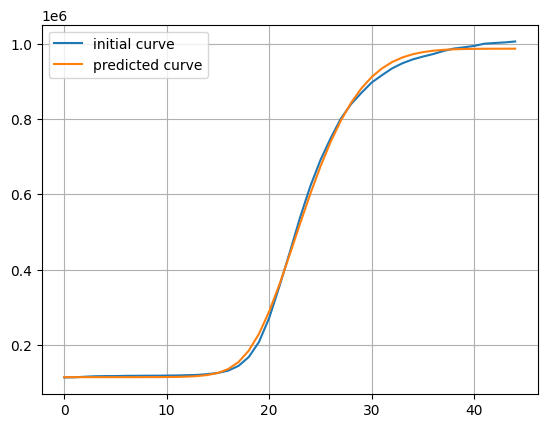

In [6]:
plt.plot(curve, label = 'initial curve')

D_e_pred = simulate_vals(D_init=Decimal(10**res.x[0]),
                    E_init=Decimal(10**res.x[1]), 
                    P_init=Decimal(10**res.x[2]), 
                    delta_e=Decimal(10**res.x[4]),
                    n_d=Decimal(10**0),
                    n_dE=Decimal(10**0),
                    k_C=Decimal(10**res.x[7]),
                    beta=Decimal(10**res.x[8]),
                    n_cycle=44)[2]

D_e_pred = np.array([float(str(x)) + 10**res.x[3] for x in D_e_pred])

plt.plot(D_e_pred, label = 'predicted curve')
plt.legend()
plt.grid()

## Validation on multiple curves

In [7]:
import pandas as pd
val_curves = pd.read_csv("data/opt_valset.csv")
val_curves.head(5)

# print(val_curves.shape)
# print(type(curve))
# print(curve.shape)

,curve_idx,target,amp_score,cq,cycle_no,rn,drn,Fn,pcr_plate,sample_type,igi_call
0,23677,MS2,2.388084,25.285821128516332,1,229219.609375,-1374.626328,229219.61,AC00DB1I,Clinical Sample,Positive
1,23677,MS2,2.388084,25.285821128516332,2,229516.937500,-1170.968546,229516.94,AC00DB1I,Clinical Sample,Positive
2,23677,MS2,2.388084,25.285821128516332,3,230569.781250,-211.795139,230569.78,AC00DB1I,Clinical Sample,Positive
3,23677,MS2,2.388084,25.285821128516332,4,231039.625000,164.378268,231039.62,AC00DB1I,Clinical Sample,Positive
4,23677,MS2,2.388084,25.285821128516332,5,230943.109375,-25.807700,230943.11,AC00DB1I,Clinical Sample,Positive


### Convert validation data into arrays

In [11]:
# Initialize an empty dictionary
curve_dict = {}

# Initialize variables to track the current cycle and array
current_cycle = None
current_array = None

# Iterate over each row in the DataFrame
for index, row in val_curves.iterrows():
    curve_idx = row['curve_idx']
    cycle_no = row['cycle_no']
    Fn = row['Fn']

    # Create a new array if cycle_no resets to 1
    if cycle_no == 1:
        current_array = []
        
    # Append Fn to the current array
    current_array.append(Fn)

    # Save the array in the dictionary with key as curve_idx
    curve_dict[curve_idx] = current_array.copy()

# Output the dictionary
print(curve_dict)

{23677: [229219.61, 229516.94, 230569.78, 231039.62, 230943.11, 230716.08, 230738.72, 231506.53, 231881.64, 231403.33, 231121.1, 231270.34, 232347.42, 232583.56, 232420.75, 232218.86, 231576.52, 231489.69, 232237.1, 232335.8, 232360.58, 233107.52, 233559.84, 234792.33, 236167.22, 239115.5, 244746.55, 251284.23, 259784.92, 269840.06, 282681.1, 297658.06, 312901.47, 329566.8, 347342.06, 364913.8, 383243.47, 399506.16, 414237.06, 426192.12], 23827: [225227.69, 225484.0, 226158.3, 226503.12, 226652.75, 227078.83, 227089.17, 227114.14, 226987.95, 226832.52, 226757.75, 226968.16, 226995.47, 227085.25, 226990.39, 226928.94, 226880.67, 226871.75, 227049.5, 227176.38, 227102.89, 227260.45, 228102.67, 229347.3, 231038.64, 234510.11, 239952.72, 247267.86, 255982.25, 267886.97, 281850.6, 297396.7, 315155.75, 334287.1, 353652.88, 374252.4, 394581.47, 413789.8, 431580.06, 445970.53], 23900: [229257.72, 229768.98, 230963.02, 231039.84, 230871.23, 230891.53, 231116.3, 231109.84, 231297.89, 231160.23, 

In [12]:
#Get target dataframe
target_data = val_curves.groupby('curve_idx').tail(1)

print(target_data.head(5))
print(target_data['sample_type'].unique())
print(target_data.groupby('sample_type').count())

print(target_data.shape)
print(len(target_data['curve_idx'].unique()))

     curve_idx  target  amp_score                  cq  cycle_no  \
39       23677     MS2   2.388084  25.285821128516332        40   
79       23827     MS2   2.411084   25.07951713476232        40   
119      23900     MS2   2.297453  25.197460254036216        40   
159      25090  S gene   2.145592   28.70093986035272        40   
199      23975     MS2   2.163302   25.14350626845352        40   

                rn            drn         Fn pcr_plate  \
39   426192.125000  191944.745915  426192.12  AC00DB1I   
79   445970.531250  218357.165625  445970.53  AC00DB1I   
119  401292.343750  170586.391506  401292.34  AC00DB1I   
159  238620.828125   56947.925824  238620.83  AC00DB1I   
199  322850.781250   97378.915372  322850.78  AC00DB1I   

                 sample_type  igi_call  
39           Clinical Sample  Positive  
79           Clinical Sample  Positive  
119          Clinical Sample  Positive  
159  Positive Control (qPCR)  Positive  
199          Clinical Sample  Positive  
['

In [13]:
#Filter down to ground truth 
ground_truth_targets = target_data[target_data['sample_type']!='Clinical Sample']
print(ground_truth_targets.shape)

(220, 11)


### Implementing eval loop

C:\Users\Sased\AppData\Local\Temp\ipykernel_35900\1690097163.py:17: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  res = minimize(func_to_optimize, init_params, method='nelder-mead', options={'xatol': 1e-1, 'disp': True})


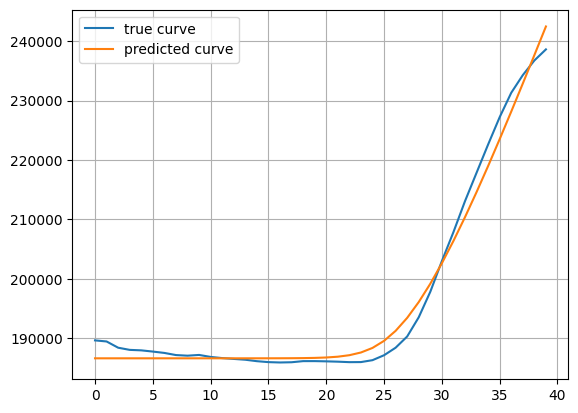

Optimization terminated successfully.
         Current function value: 4588303095.130161
         Iterations: 662
         Function evaluations: 1027


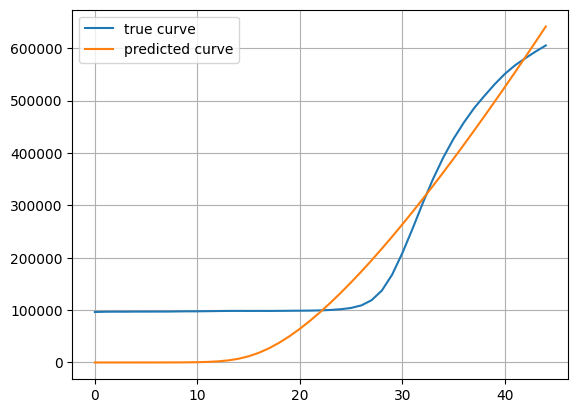

Optimization terminated successfully.
         Current function value: 17480482.299938
         Iterations: 913
         Function evaluations: 1398


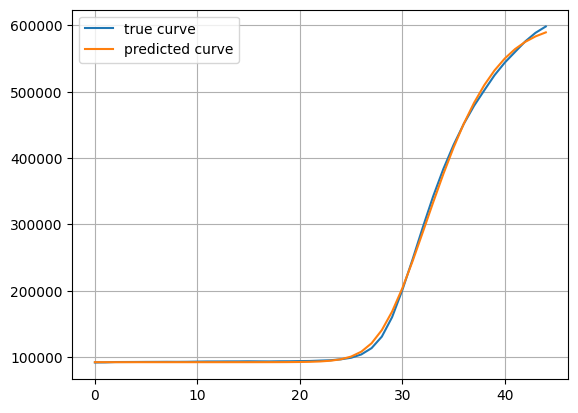

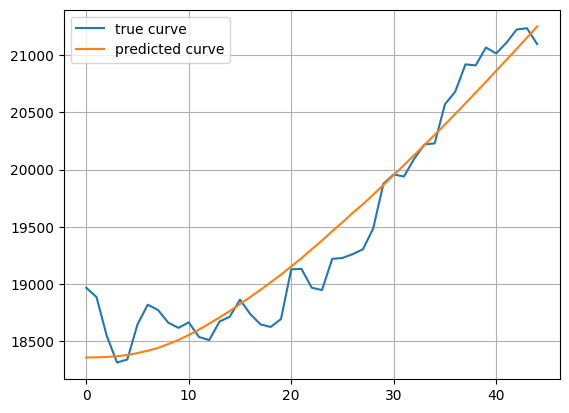

Optimization terminated successfully.
         Current function value: 66594474.266820
         Iterations: 682
         Function evaluations: 1067


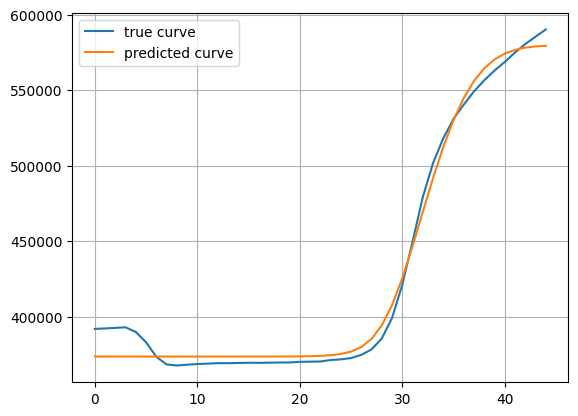

Optimization terminated successfully.
         Current function value: 88632665.840755
         Iterations: 884
         Function evaluations: 1346


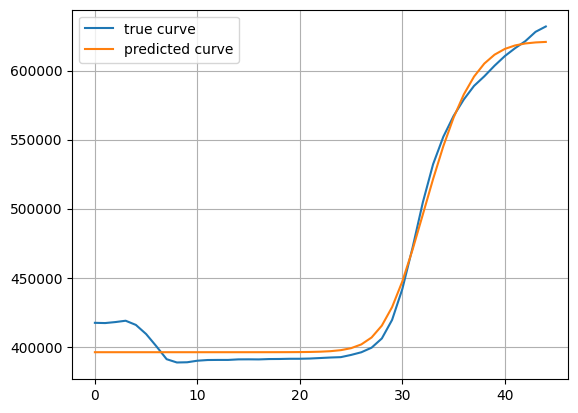

Optimization terminated successfully.
         Current function value: 19871.593628
         Iterations: 687
         Function evaluations: 1054


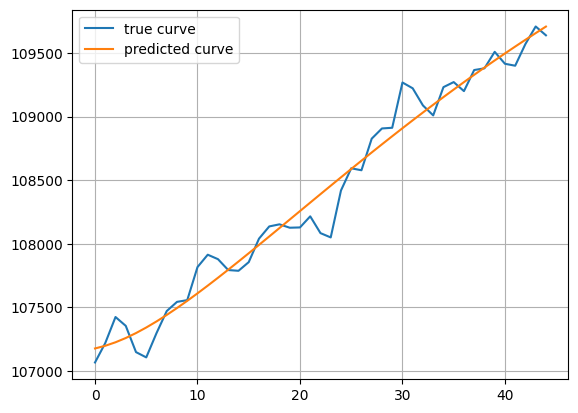

Optimization terminated successfully.
         Current function value: 10817016.700729
         Iterations: 636
         Function evaluations: 1006


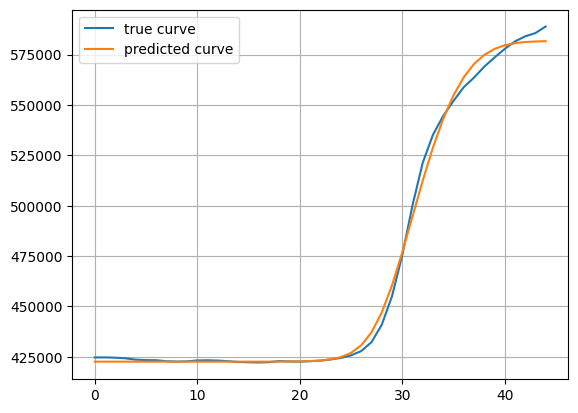

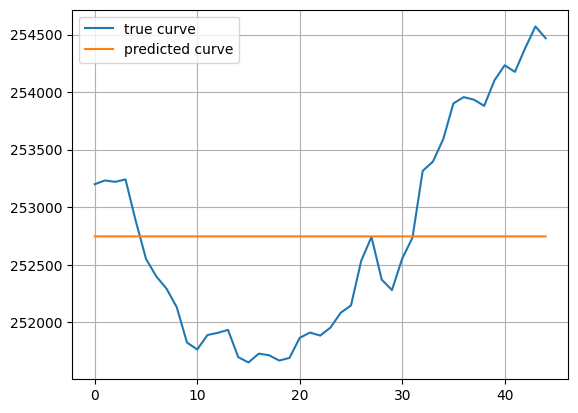

Optimization terminated successfully.
         Current function value: 38881.676211
         Iterations: 721
         Function evaluations: 1114


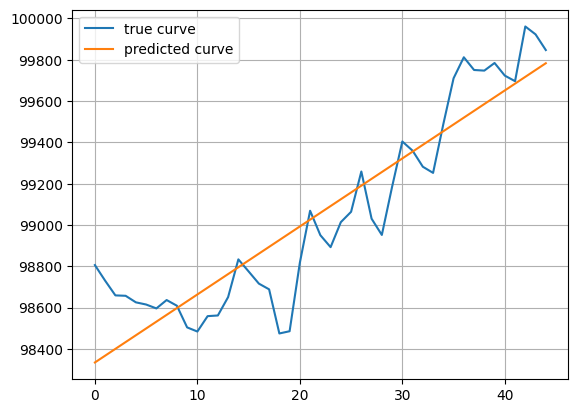

Optimization terminated successfully.
         Current function value: 138877.933610
         Iterations: 1019
         Function evaluations: 1554


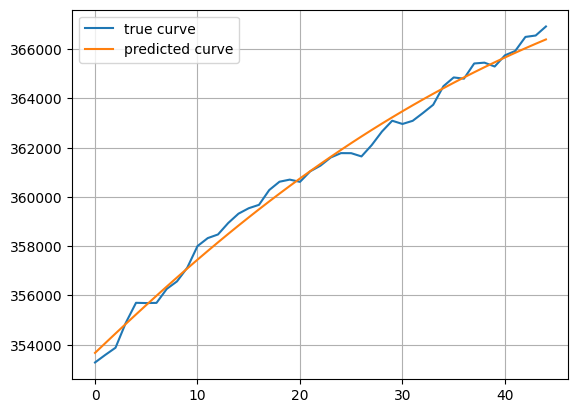

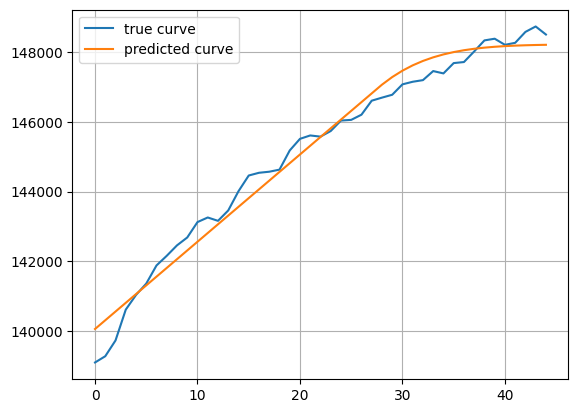

Optimization terminated successfully.
         Current function value: 2133342238.887941
         Iterations: 422
         Function evaluations: 712


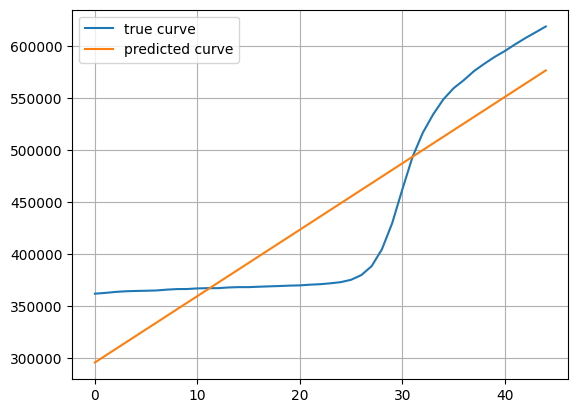

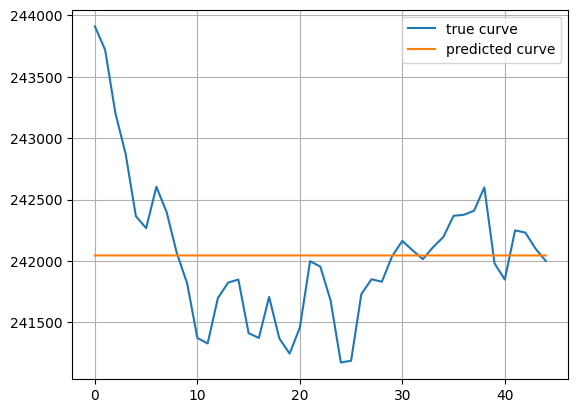

Optimization terminated successfully.
         Current function value: 14215.149830
         Iterations: 764
         Function evaluations: 1167


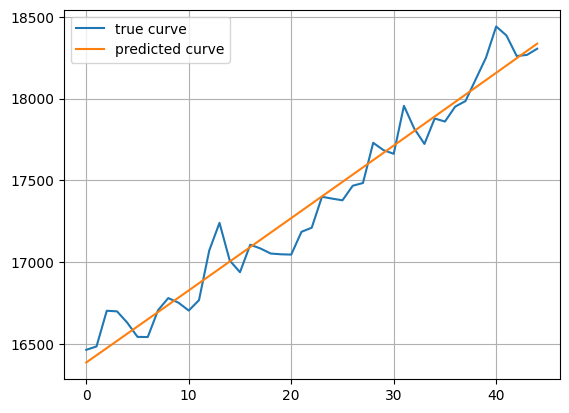

Optimization terminated successfully.
         Current function value: 3785609.187109
         Iterations: 483
         Function evaluations: 771


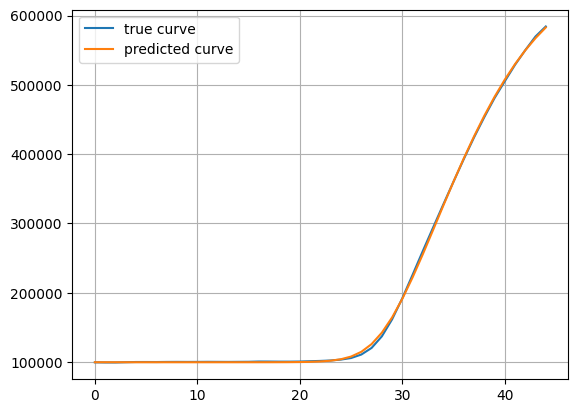

Optimization terminated successfully.
         Current function value: 49234.906338
         Iterations: 668
         Function evaluations: 1035


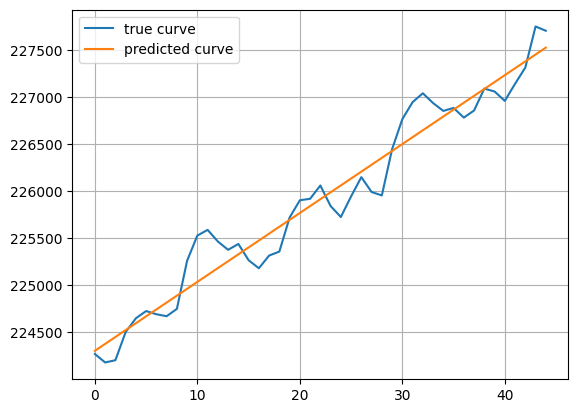

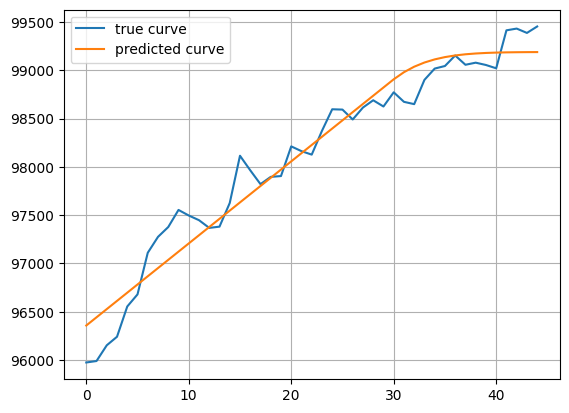

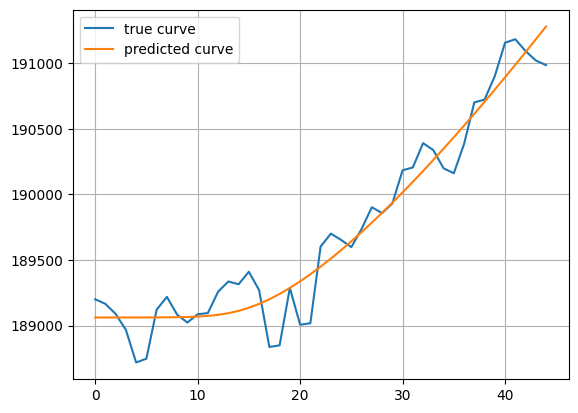

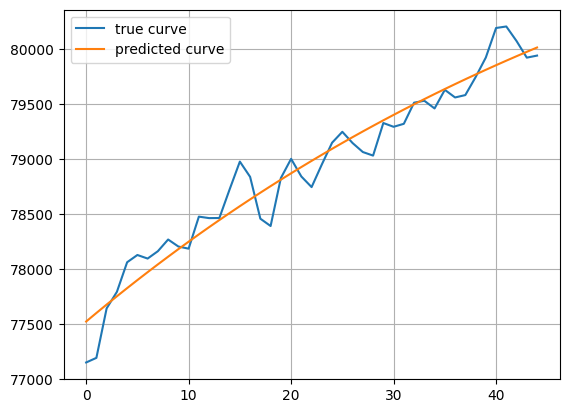

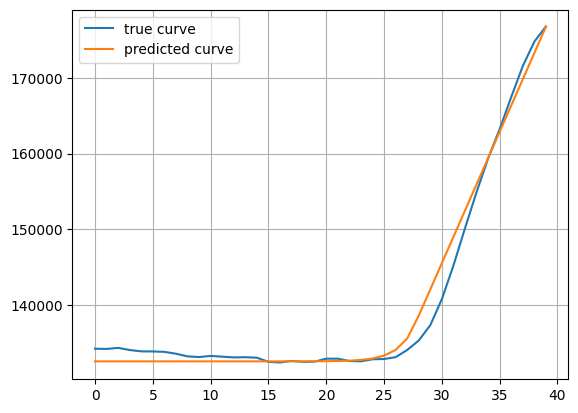

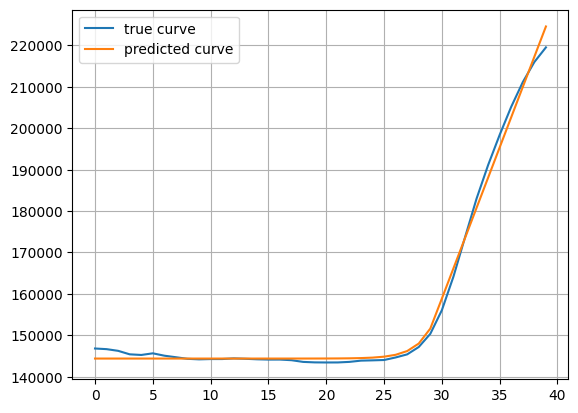

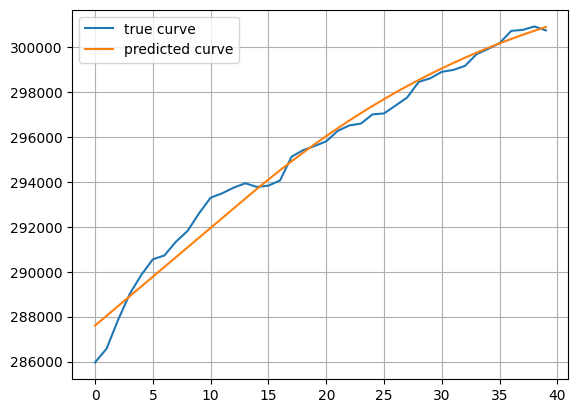

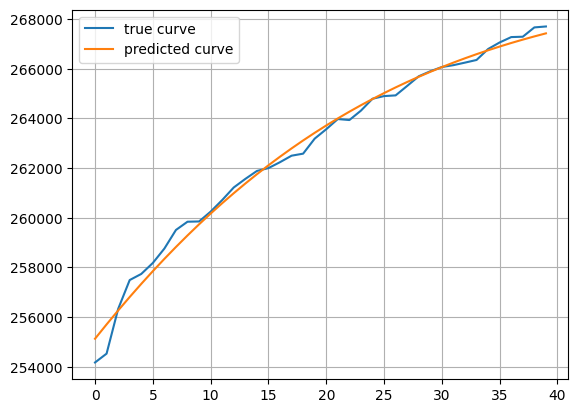

Optimization terminated successfully.
         Current function value: 18778017.621073
         Iterations: 613
         Function evaluations: 944


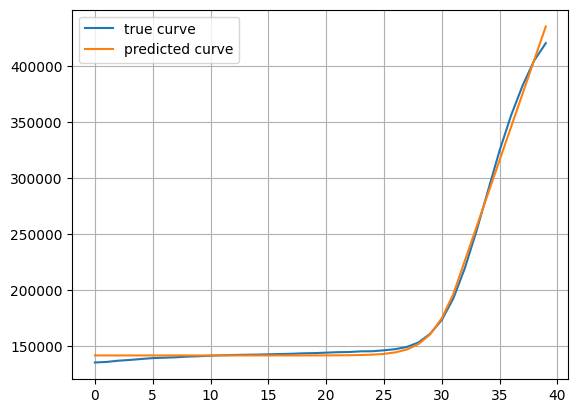

Optimization terminated successfully.
         Current function value: 2119737.901799
         Iterations: 626
         Function evaluations: 964


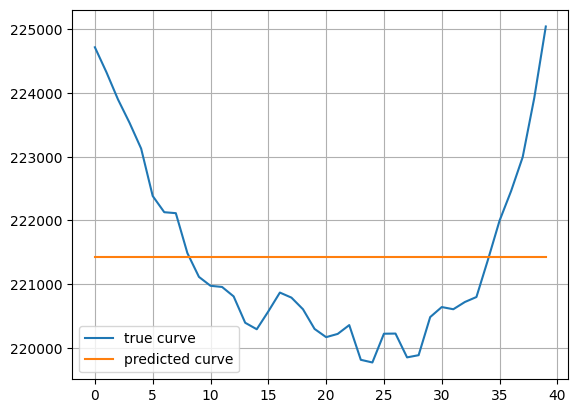

Optimization terminated successfully.
         Current function value: 1363376.920020
         Iterations: 627
         Function evaluations: 979


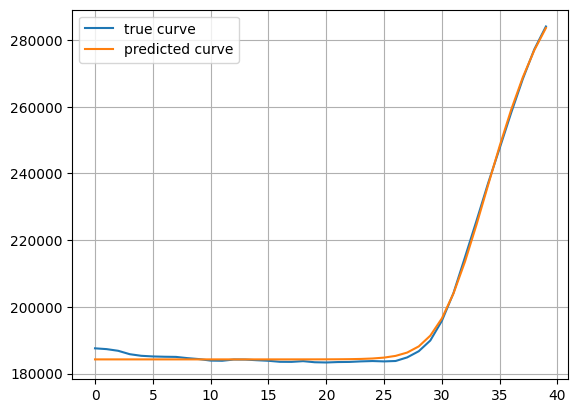

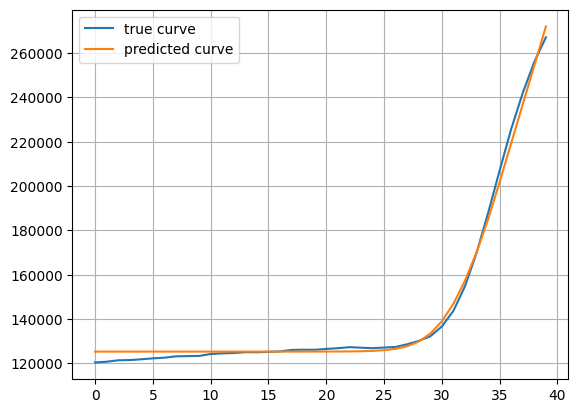

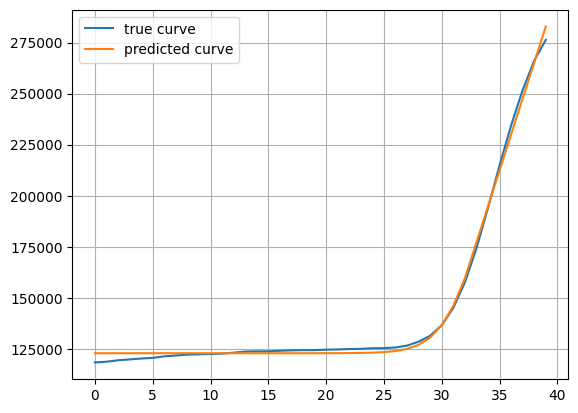

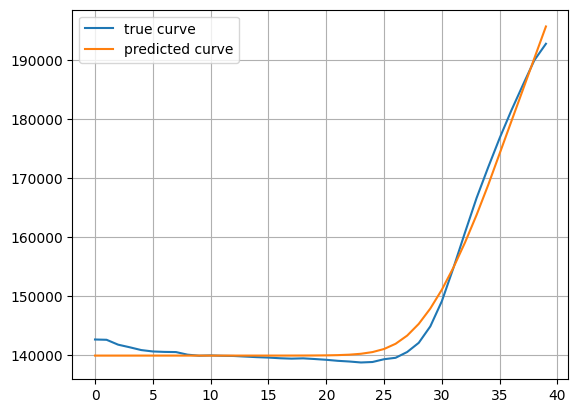

Optimization terminated successfully.
         Current function value: 999938.039317
         Iterations: 669
         Function evaluations: 1051


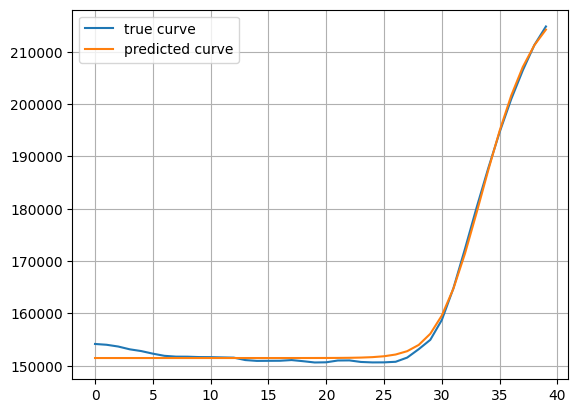

Optimization terminated successfully.
         Current function value: 977112.059512
         Iterations: 703
         Function evaluations: 1088


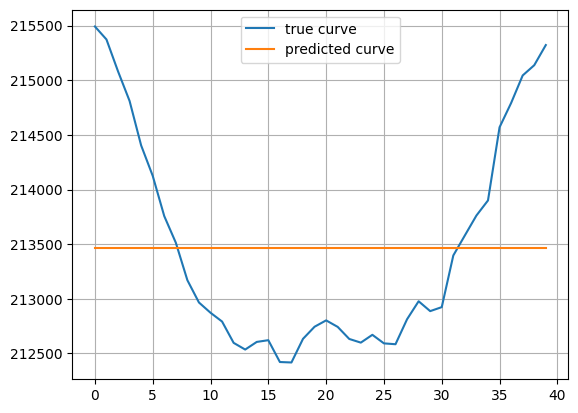

Optimization terminated successfully.
         Current function value: 27250.715499
         Iterations: 1127
         Function evaluations: 1698


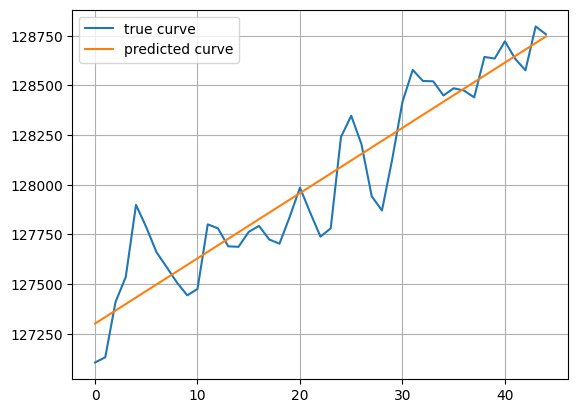

Optimization terminated successfully.
         Current function value: 15421.501696
         Iterations: 444
         Function evaluations: 701


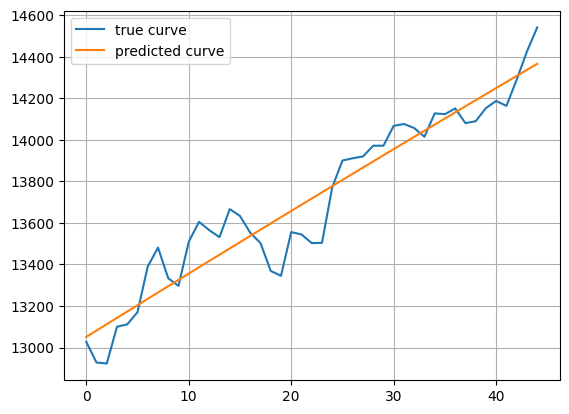

Optimization terminated successfully.
         Current function value: 3610719.979436
         Iterations: 653
         Function evaluations: 1026


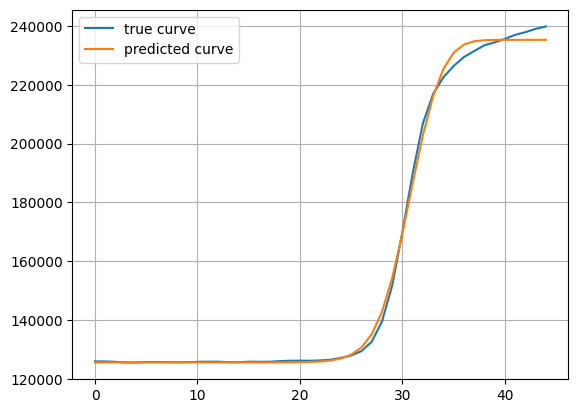

Optimization terminated successfully.
         Current function value: 3916036.076817
         Iterations: 939
         Function evaluations: 1433


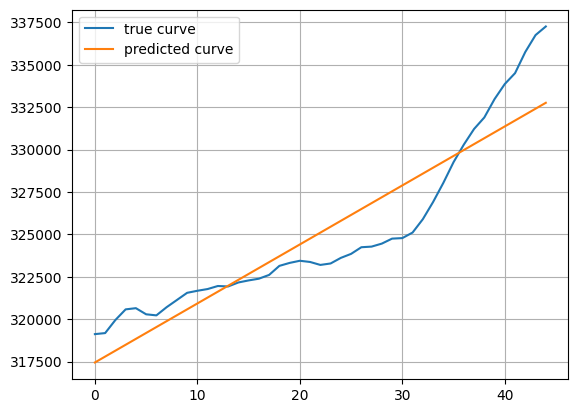

Optimization terminated successfully.
         Current function value: 6235980.654189
         Iterations: 673
         Function evaluations: 1054


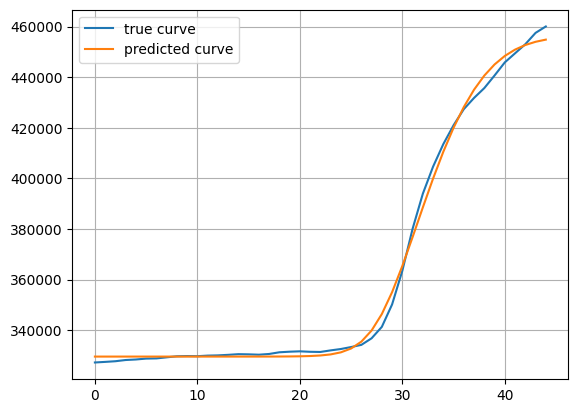

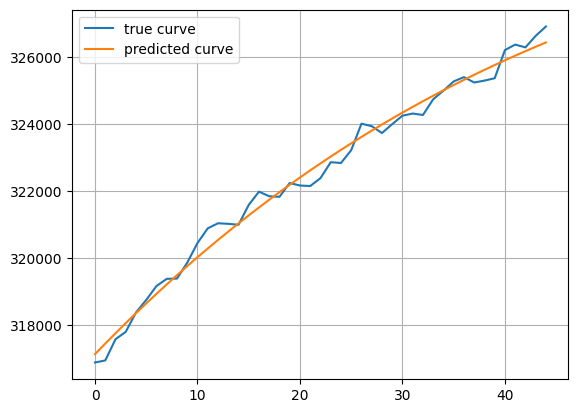

Optimization terminated successfully.
         Current function value: 42773.095571
         Iterations: 469
         Function evaluations: 762


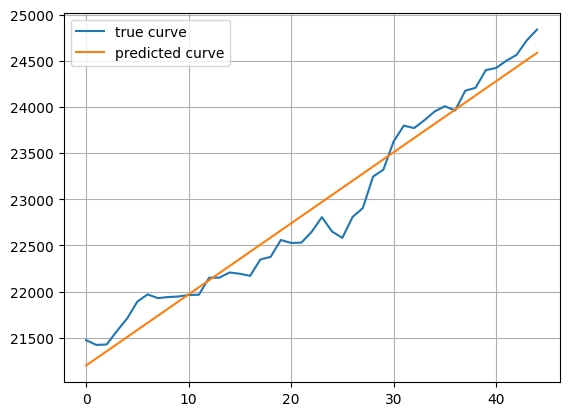

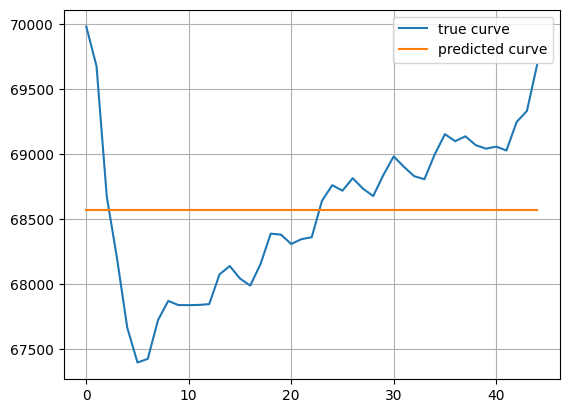

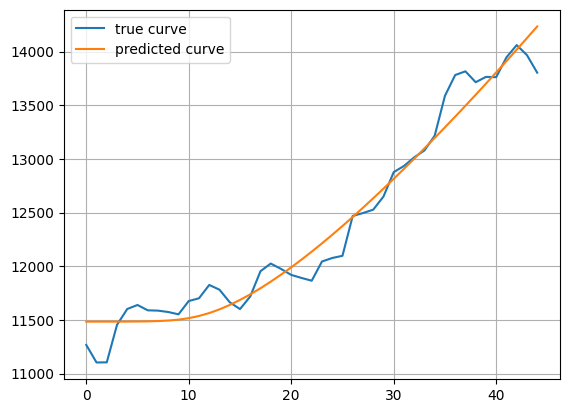

Optimization terminated successfully.
         Current function value: 306953.198308
         Iterations: 551
         Function evaluations: 832


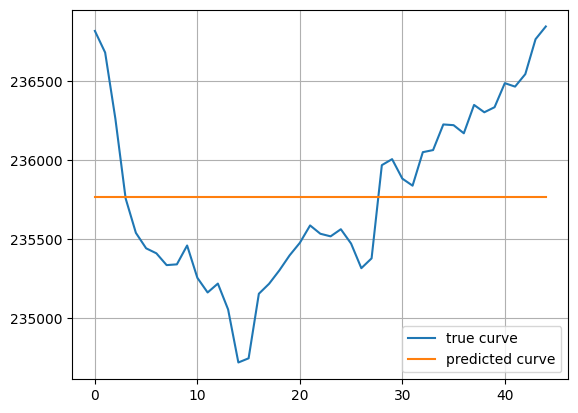

Optimization terminated successfully.
         Current function value: 11846641.281549
         Iterations: 1094
         Function evaluations: 1669


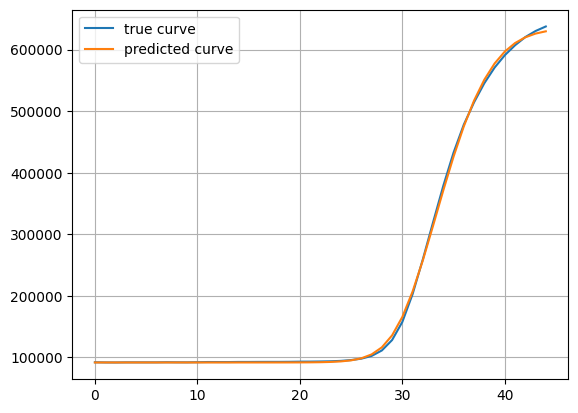

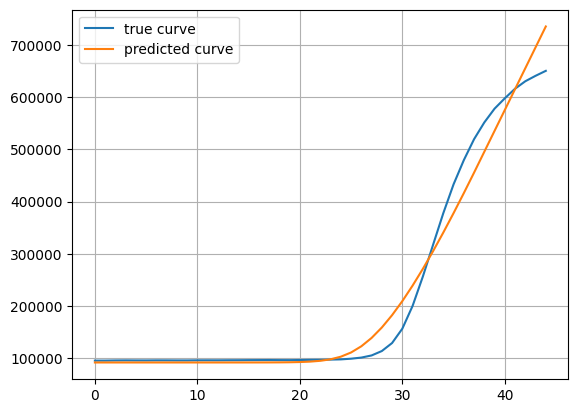

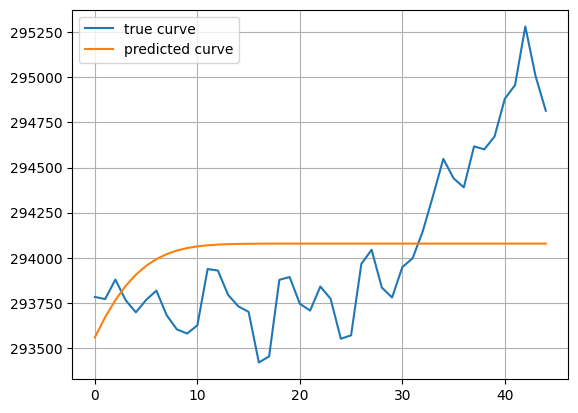

Optimization terminated successfully.
         Current function value: 14790545.960970
         Iterations: 1031
         Function evaluations: 1584


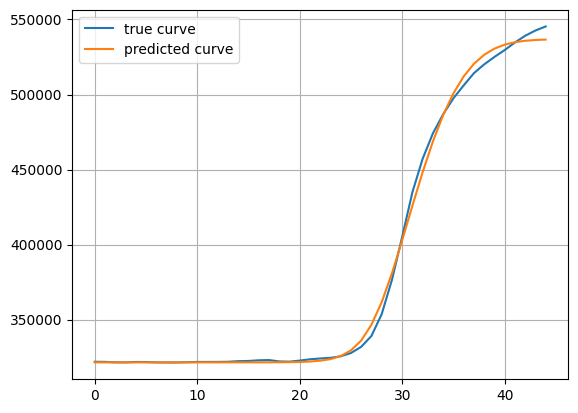

Optimization terminated successfully.
         Current function value: 16992497.188268
         Iterations: 710
         Function evaluations: 1107


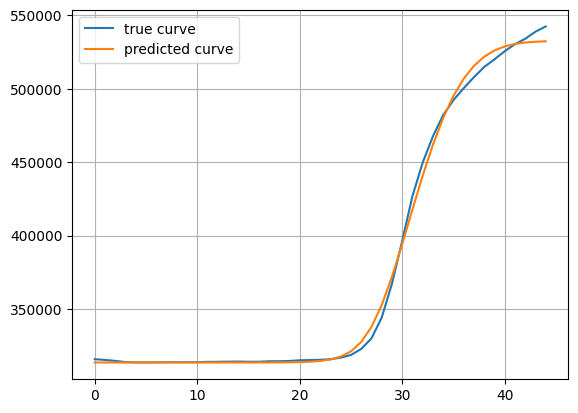

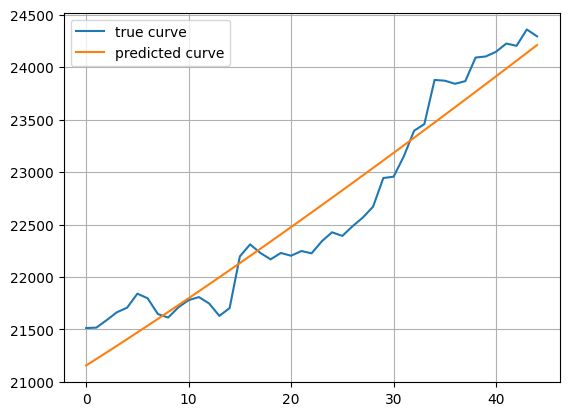

Optimization terminated successfully.
         Current function value: 1738295339.965623
         Iterations: 395
         Function evaluations: 665


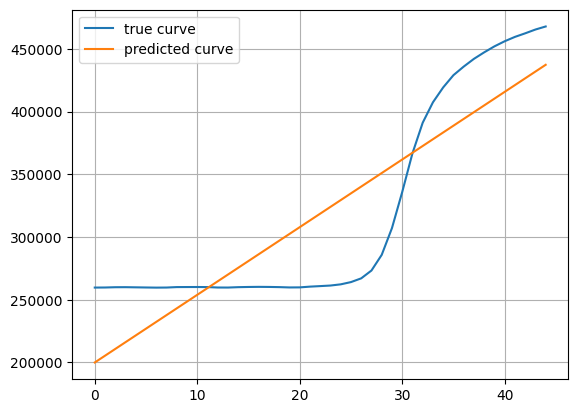

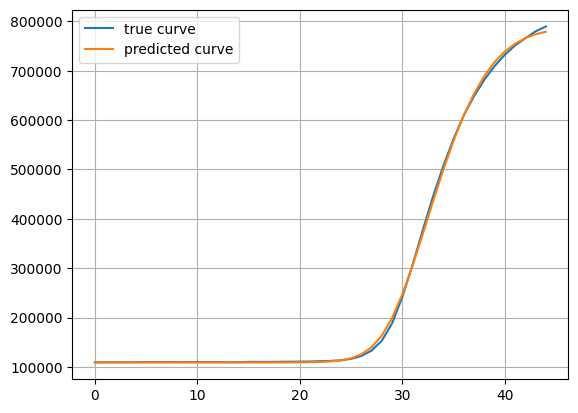

Optimization terminated successfully.
         Current function value: 10302.951286
         Iterations: 673
         Function evaluations: 1029


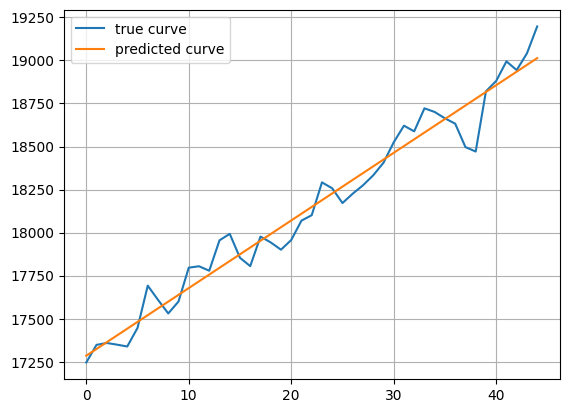

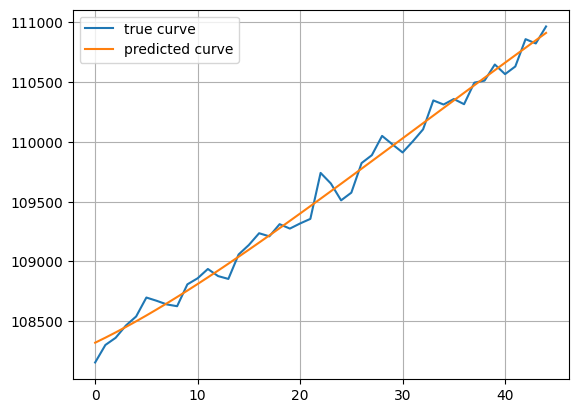

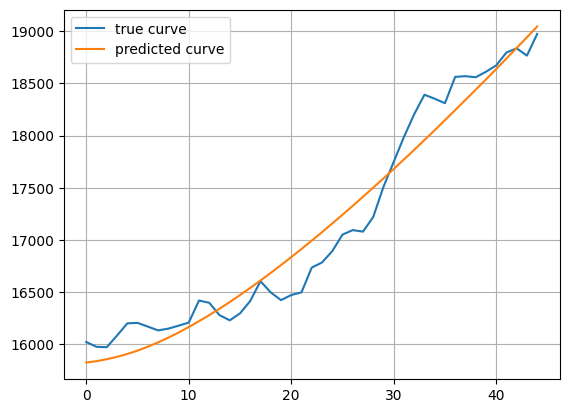

Optimization terminated successfully.
         Current function value: 41246.369262
         Iterations: 967
         Function evaluations: 1455


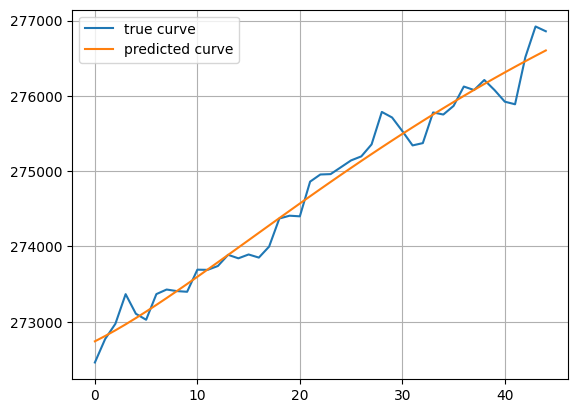

Optimization terminated successfully.
         Current function value: 10909297.382178
         Iterations: 422
         Function evaluations: 702


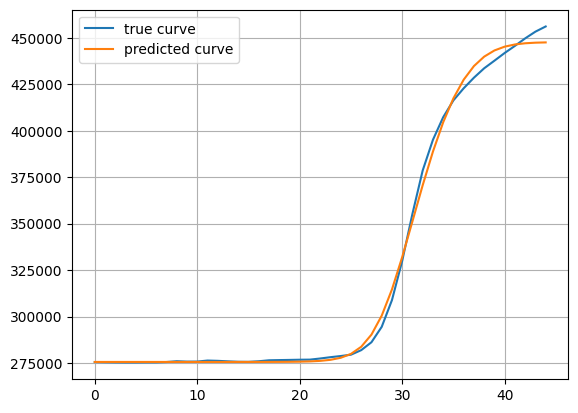

Optimization terminated successfully.
         Current function value: 11203624.563613
         Iterations: 564
         Function evaluations: 893


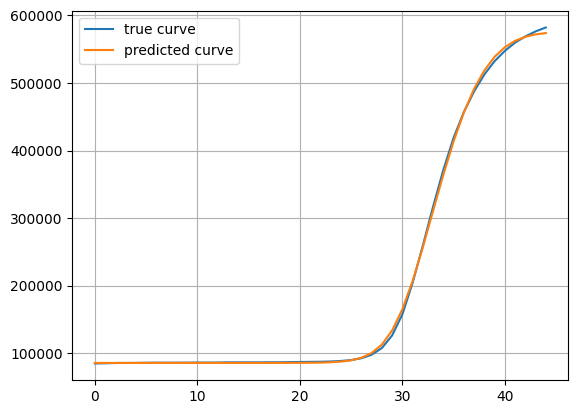

Optimization terminated successfully.
         Current function value: 14471723.823089
         Iterations: 871
         Function evaluations: 1348


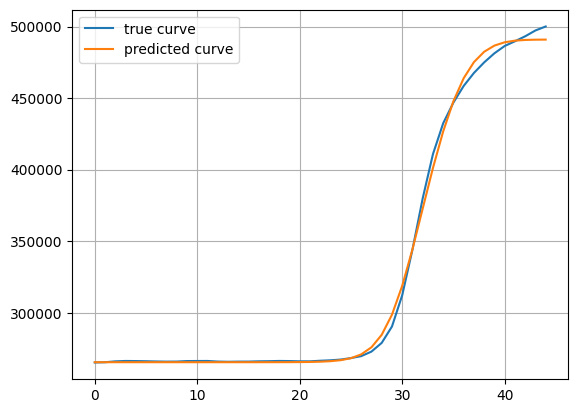

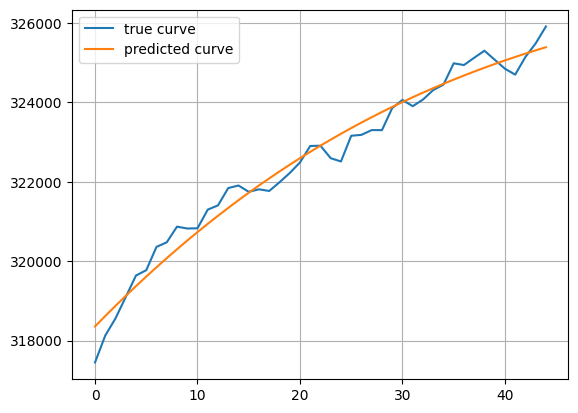

Optimization terminated successfully.
         Current function value: 14701536.885492
         Iterations: 662
         Function evaluations: 1031


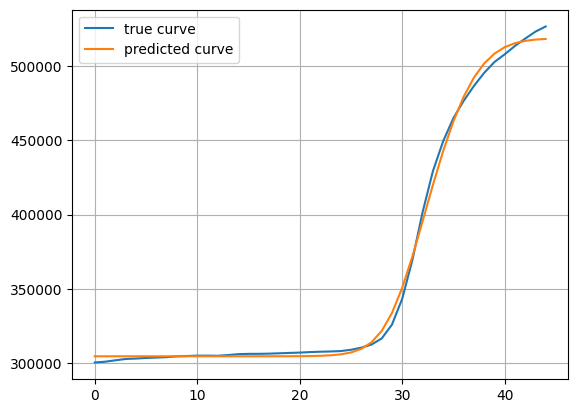

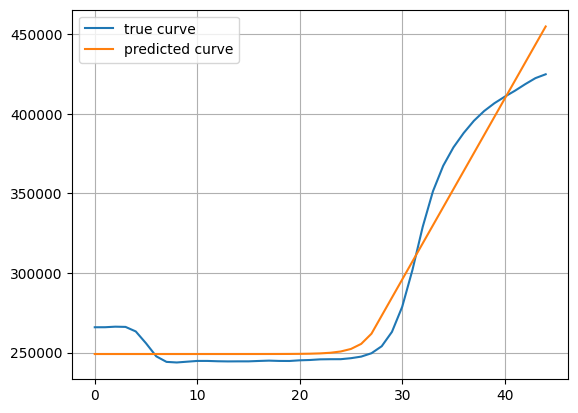

Optimization terminated successfully.
         Current function value: 179913976.640105
         Iterations: 1021
         Function evaluations: 1546


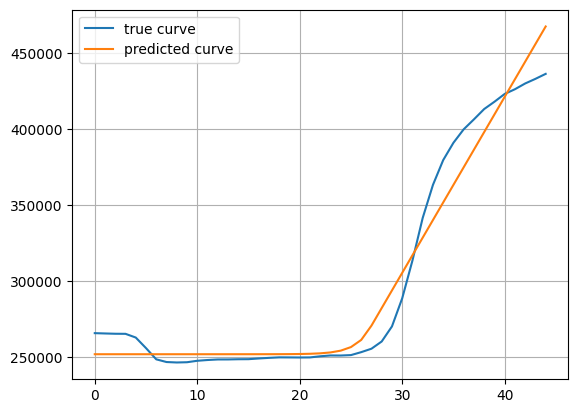

Optimization terminated successfully.
         Current function value: 17278551.116321
         Iterations: 815
         Function evaluations: 1254


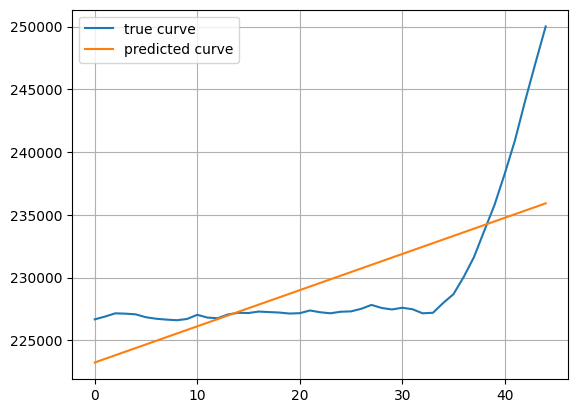

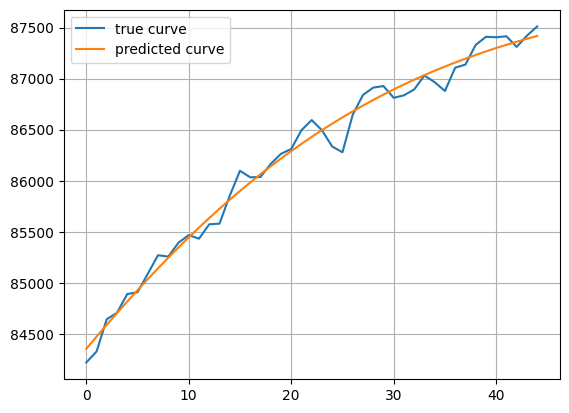

Optimization terminated successfully.
         Current function value: 8113457.879277
         Iterations: 819
         Function evaluations: 1259


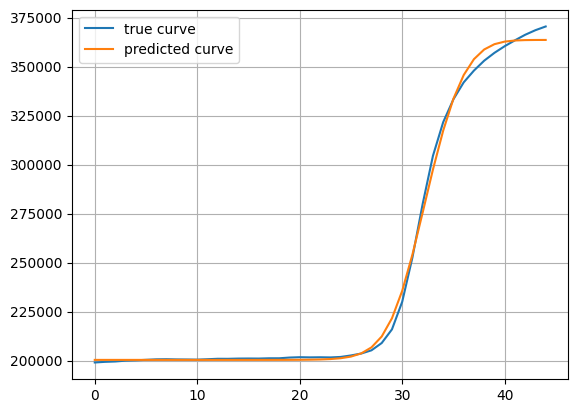

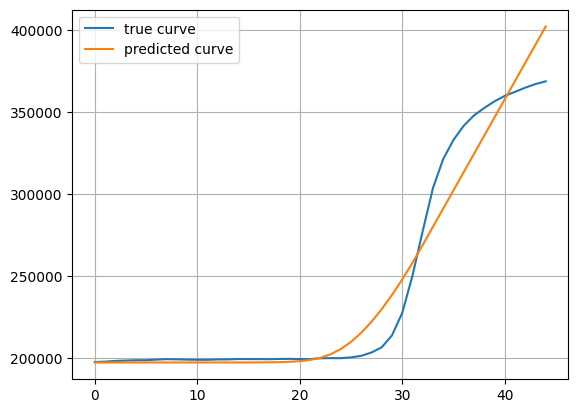

Optimization terminated successfully.
         Current function value: 442600.322906
         Iterations: 773
         Function evaluations: 1194


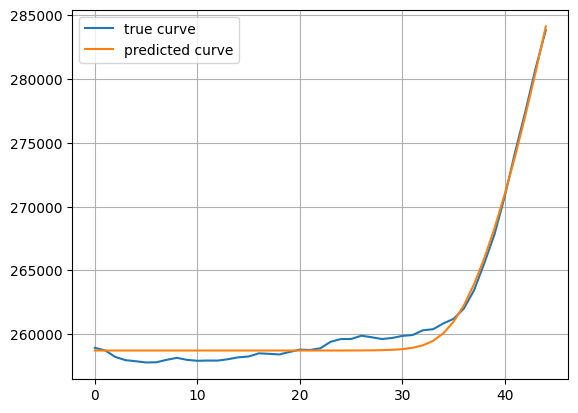

Optimization terminated successfully.
         Current function value: 688071.649102
         Iterations: 614
         Function evaluations: 1403


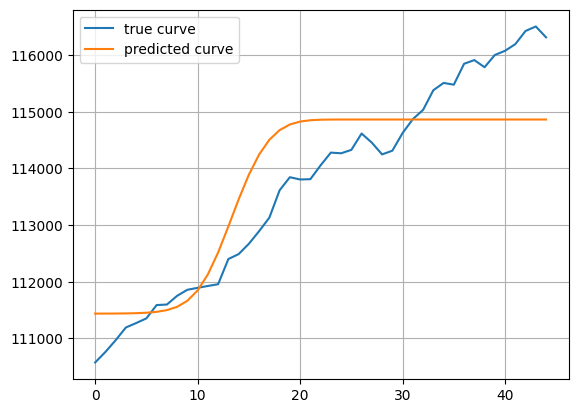

Optimization terminated successfully.
         Current function value: 500249800.786179
         Iterations: 800
         Function evaluations: 1407


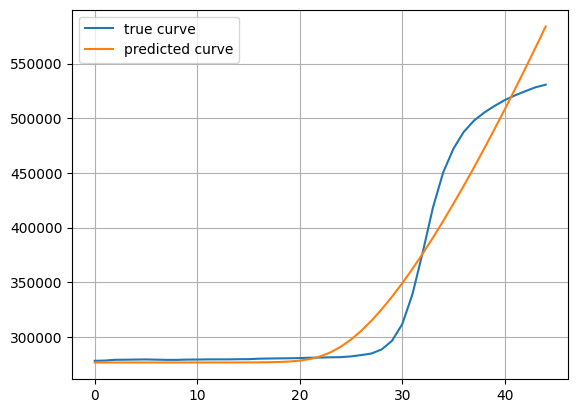

Optimization terminated successfully.
         Current function value: 1247910.258981
         Iterations: 665
         Function evaluations: 1035


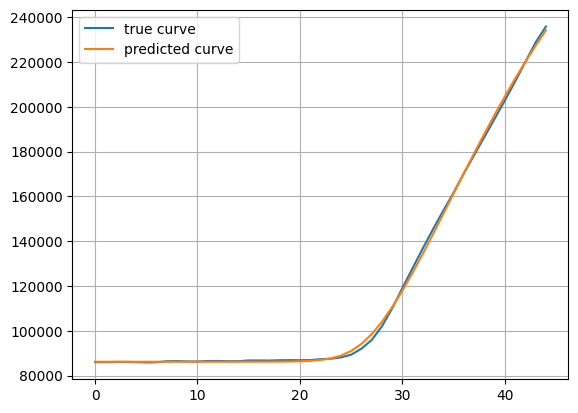

Optimization terminated successfully.
         Current function value: 1175720.687859
         Iterations: 1041
         Function evaluations: 1587


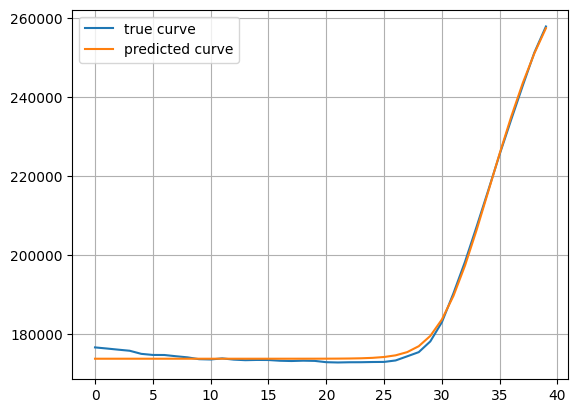

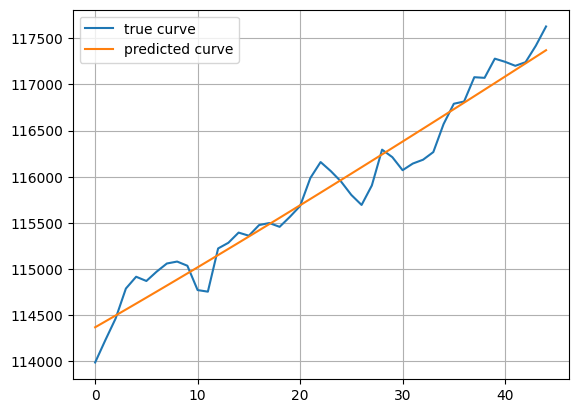

Optimization terminated successfully.
         Current function value: 276976.436174
         Iterations: 678
         Function evaluations: 1038


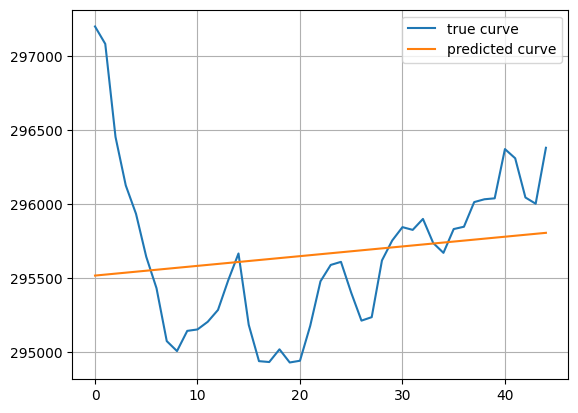

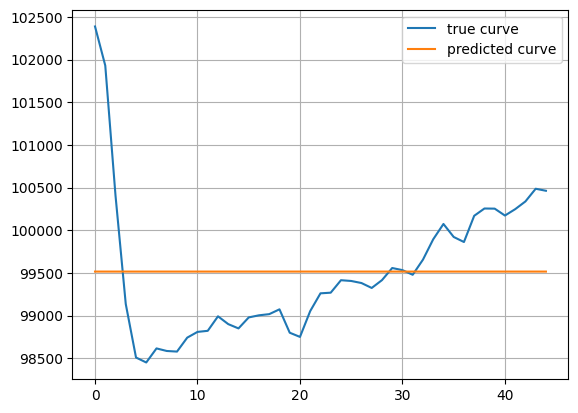

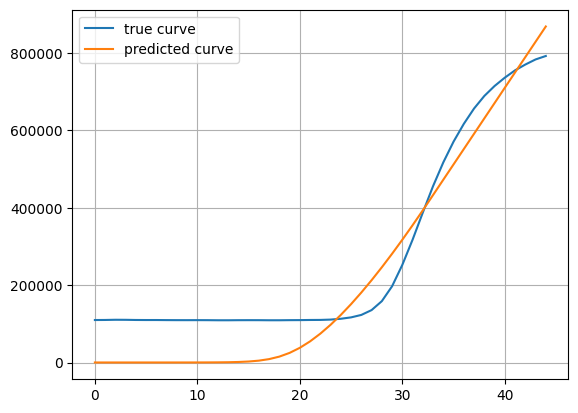

Optimization terminated successfully.
         Current function value: 13464.974612
         Iterations: 713
         Function evaluations: 1100


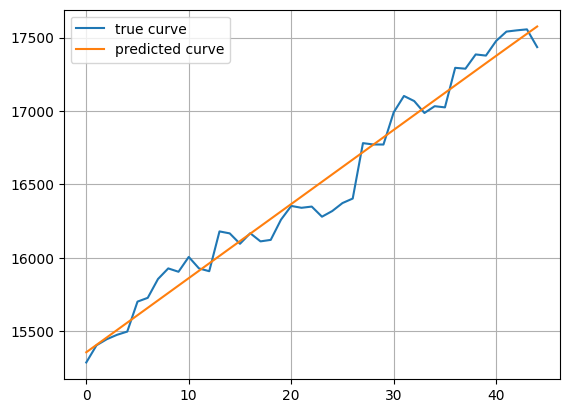

Optimization terminated successfully.
         Current function value: 17529.418579
         Iterations: 533
         Function evaluations: 825


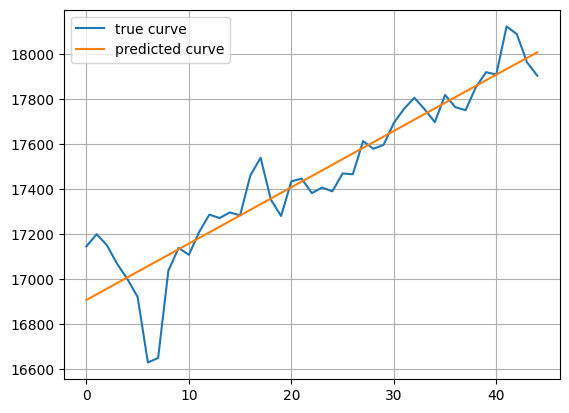

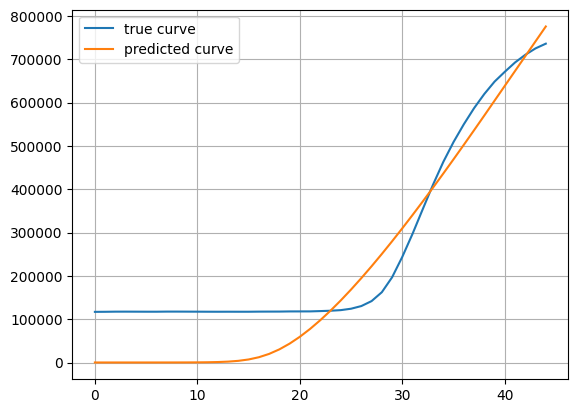

Optimization terminated successfully.
         Current function value: 19511697.931306
         Iterations: 636
         Function evaluations: 1003


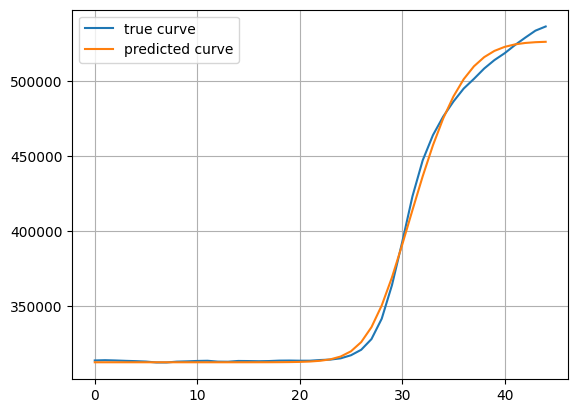

Optimization terminated successfully.
         Current function value: 62690.969138
         Iterations: 729
         Function evaluations: 1112


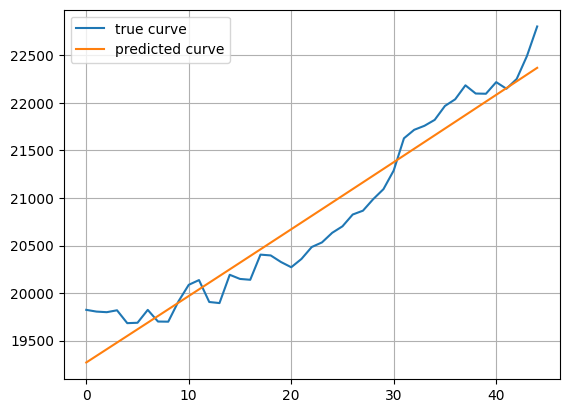

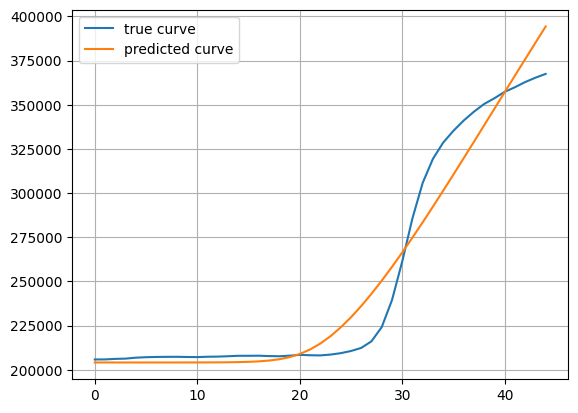

Optimization terminated successfully.
         Current function value: 5798940096.160295
         Iterations: 827
         Function evaluations: 1266


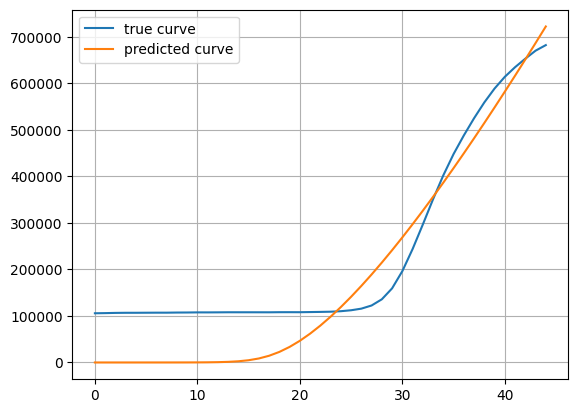

Optimization terminated successfully.
         Current function value: 9157890.930064
         Iterations: 514
         Function evaluations: 832


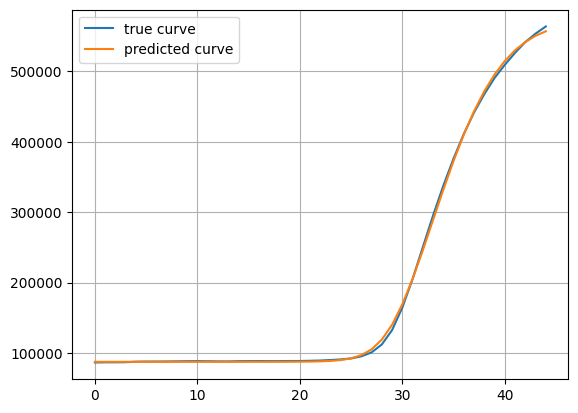

Optimization terminated successfully.
         Current function value: 8013014.819365
         Iterations: 1141
         Function evaluations: 1724


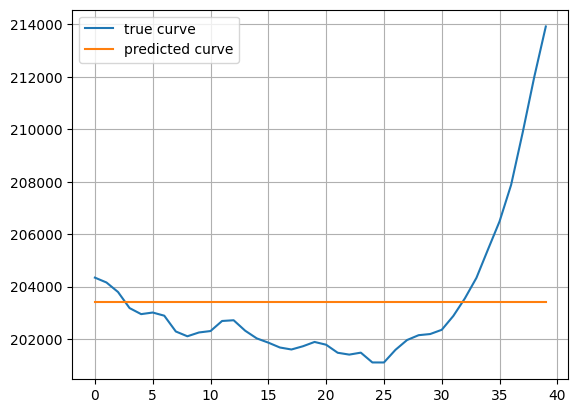

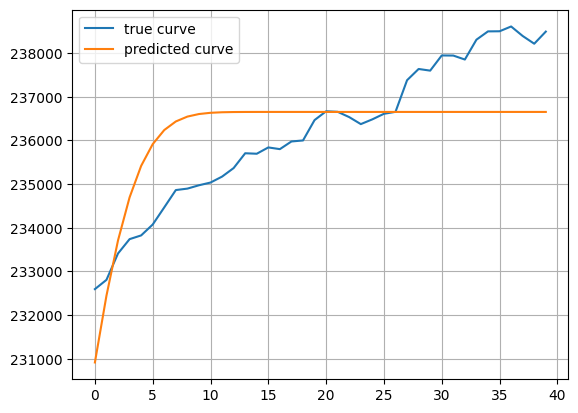

Optimization terminated successfully.
         Current function value: 717323.232853
         Iterations: 583
         Function evaluations: 915


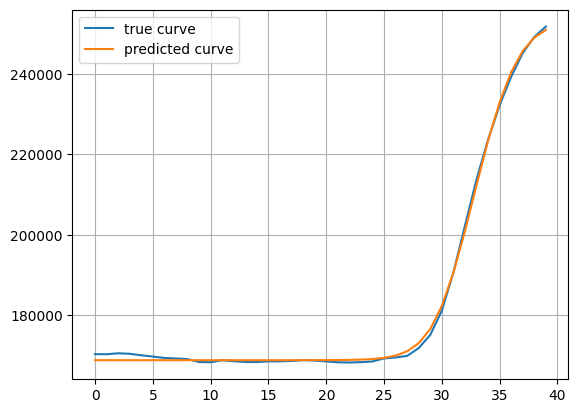

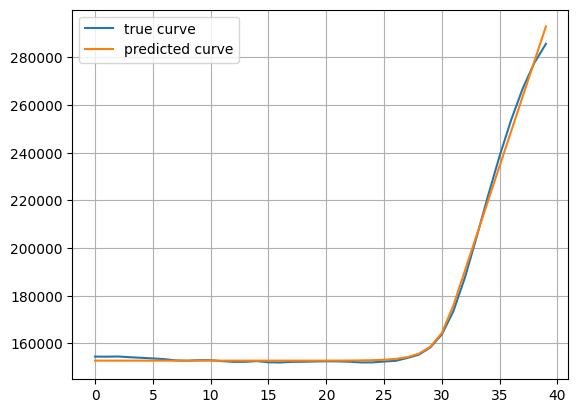

Optimization terminated successfully.
         Current function value: 33477.039979
         Iterations: 1184
         Function evaluations: 1769


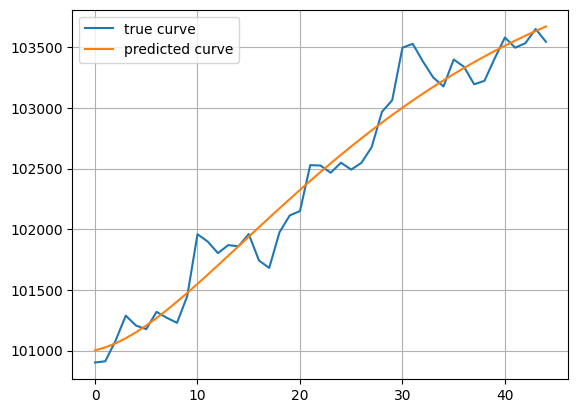

Optimization terminated successfully.
         Current function value: 216711127.182642
         Iterations: 1008
         Function evaluations: 1495


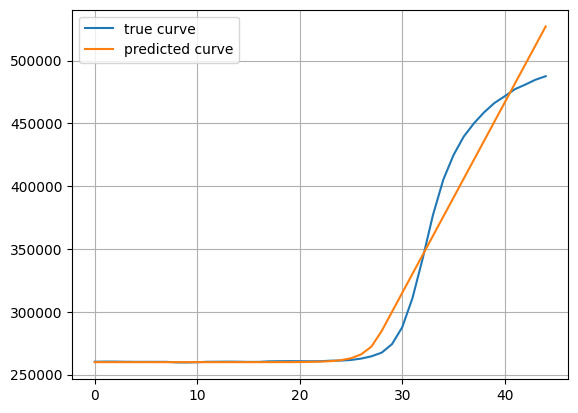

Optimization terminated successfully.
         Current function value: 732915.192228
         Iterations: 959
         Function evaluations: 1469


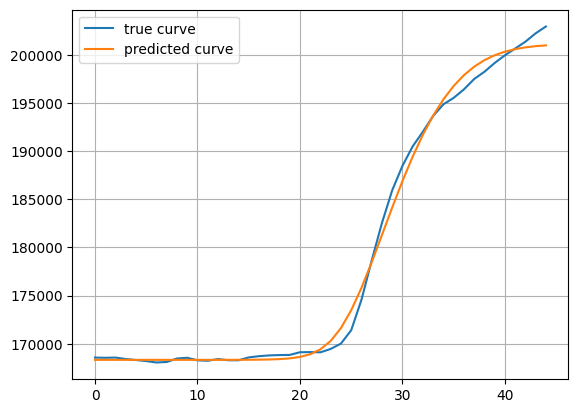

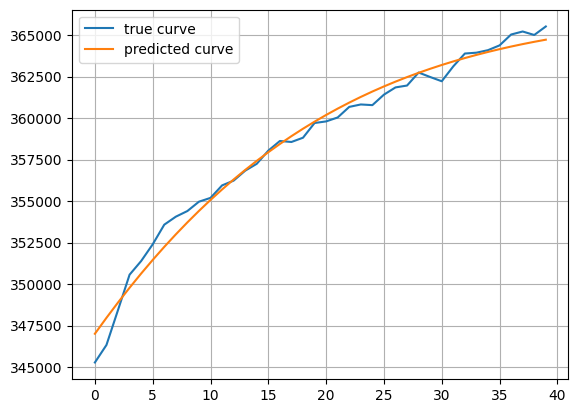

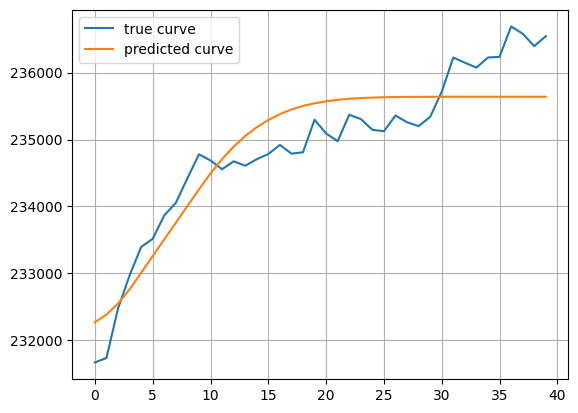

Optimization terminated successfully.
         Current function value: 1623947.775333
         Iterations: 1011
         Function evaluations: 1558


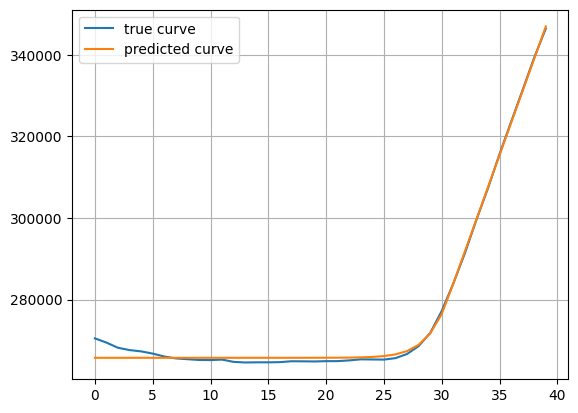

Optimization terminated successfully.
         Current function value: 2192035.017315
         Iterations: 984
         Function evaluations: 1495


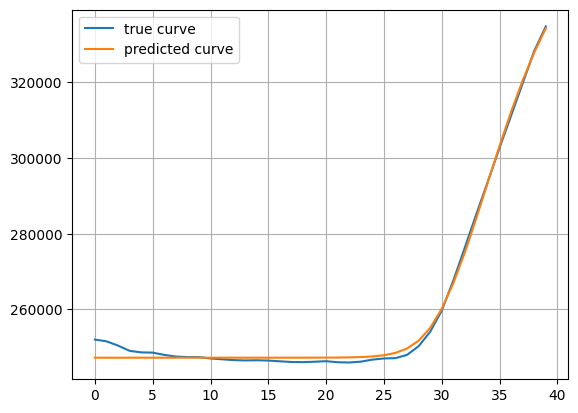

Optimization terminated successfully.
         Current function value: 223612.078140
         Iterations: 615
         Function evaluations: 941


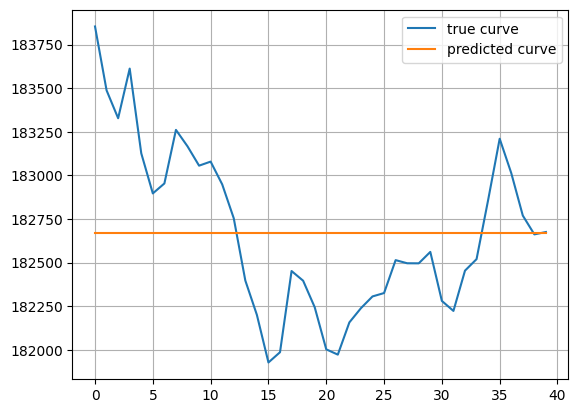

Optimization terminated successfully.
         Current function value: 799634.259545
         Iterations: 613
         Function evaluations: 964


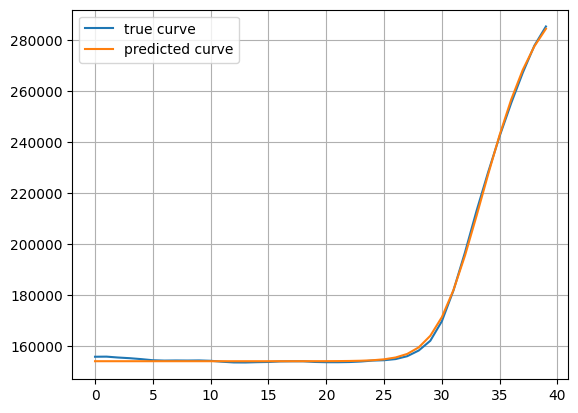

Optimization terminated successfully.
         Current function value: 613960.779316
         Iterations: 1039
         Function evaluations: 1596


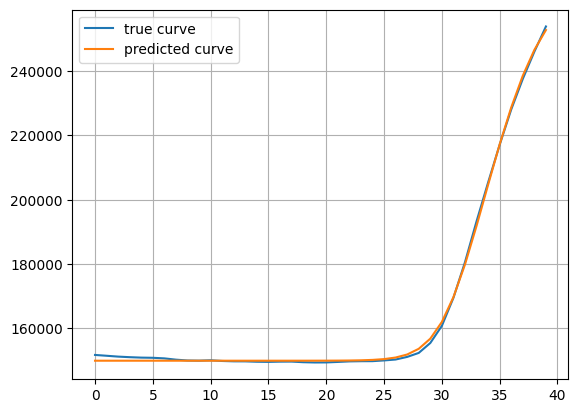

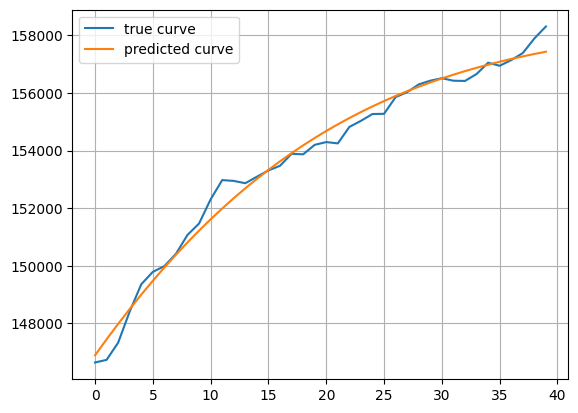

Optimization terminated successfully.
         Current function value: 1184024.186124
         Iterations: 576
         Function evaluations: 907


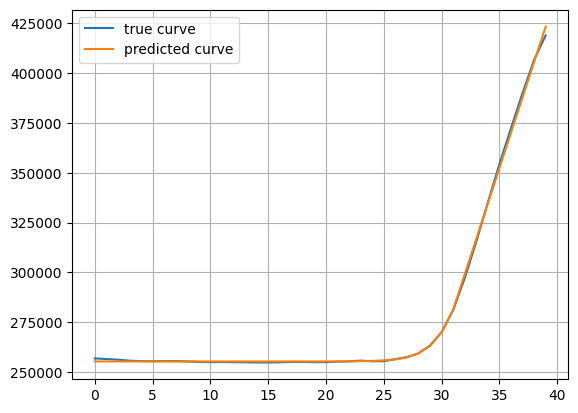

Optimization terminated successfully.
         Current function value: 2288776.401590
         Iterations: 635
         Function evaluations: 977


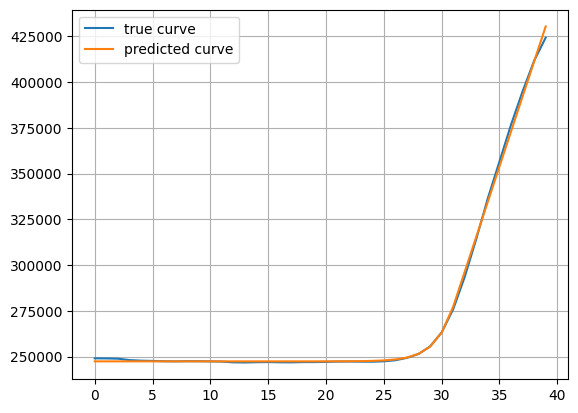

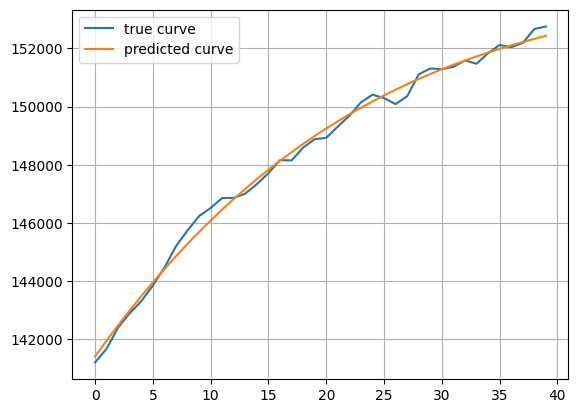

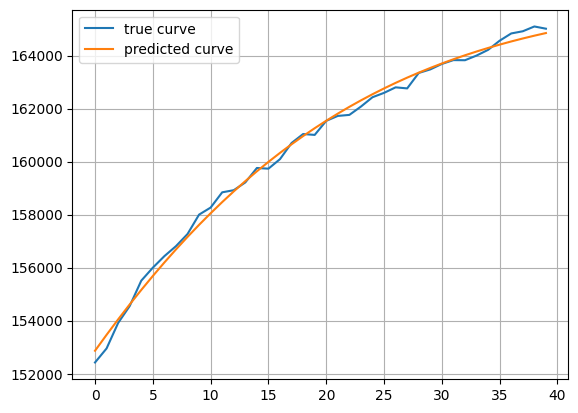

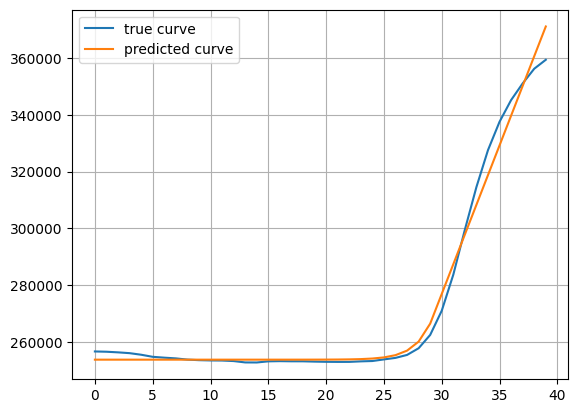

Optimization terminated successfully.
         Current function value: 2700692.367836
         Iterations: 989
         Function evaluations: 1502


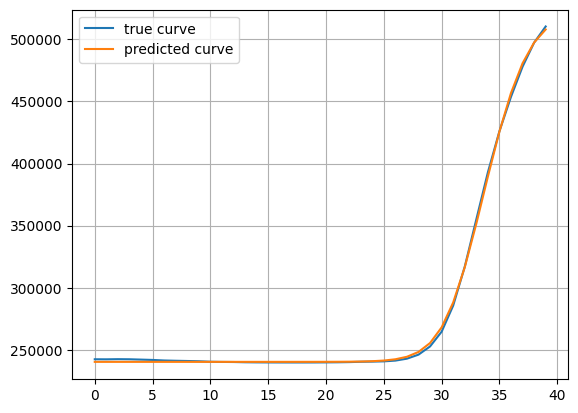

Optimization terminated successfully.
         Current function value: 108075481.692747
         Iterations: 437
         Function evaluations: 707


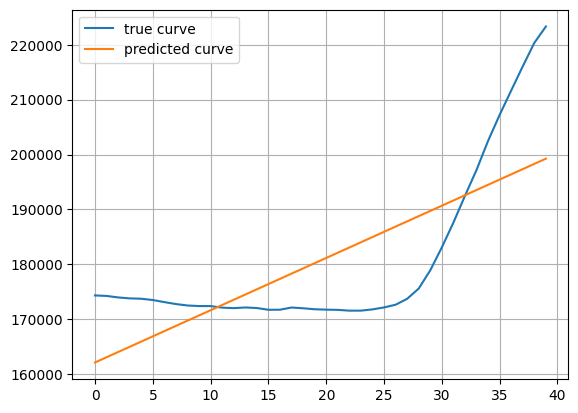

Optimization terminated successfully.
         Current function value: 764211.802736
         Iterations: 953
         Function evaluations: 1443


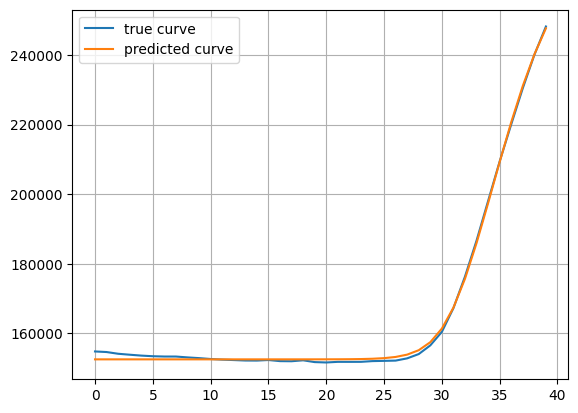

Optimization terminated successfully.
         Current function value: 31829.885437
         Iterations: 640
         Function evaluations: 987


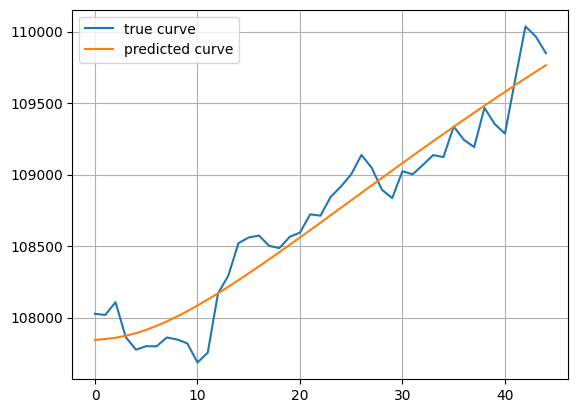

Optimization terminated successfully.
         Current function value: 22429.471987
         Iterations: 399
         Function evaluations: 642


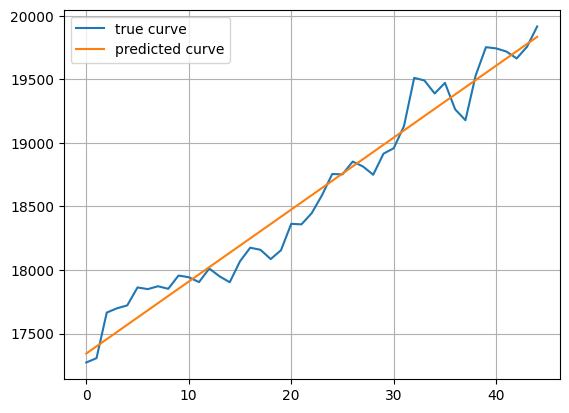

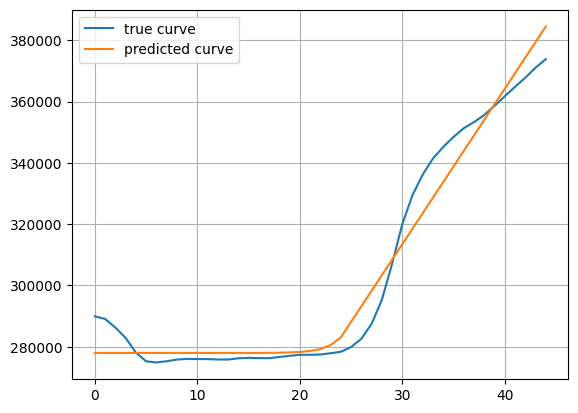

Optimization terminated successfully.
         Current function value: 1448056026.693453
         Iterations: 1172
         Function evaluations: 1705


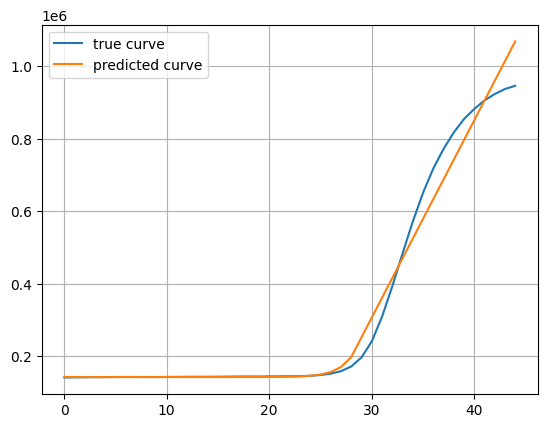

Optimization terminated successfully.
         Current function value: 21117605.859122
         Iterations: 567
         Function evaluations: 901


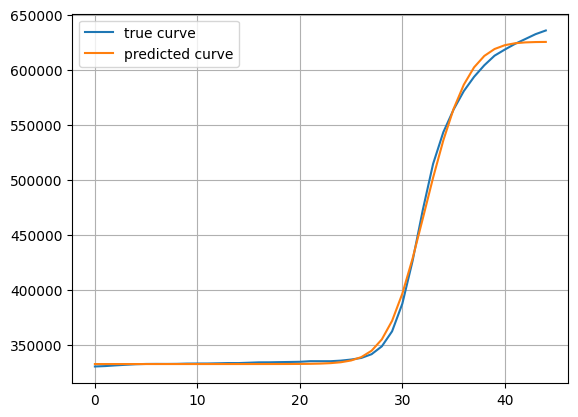

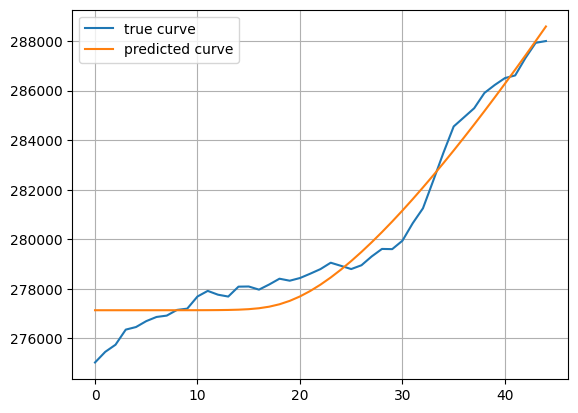

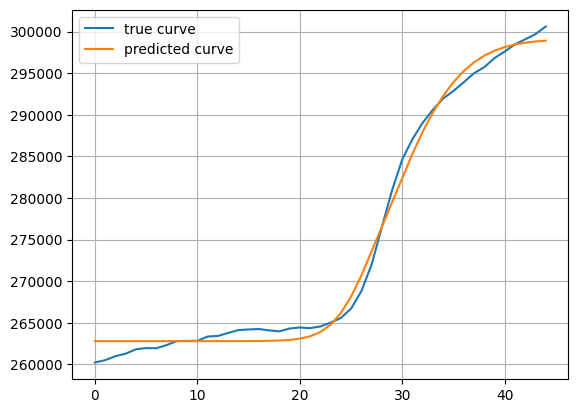

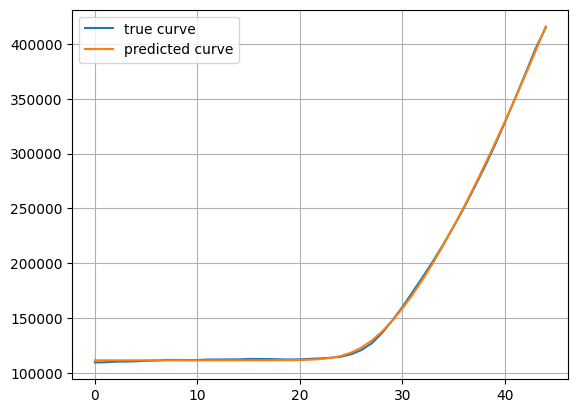

Optimization terminated successfully.
         Current function value: 6844084.942071
         Iterations: 889
         Function evaluations: 1359


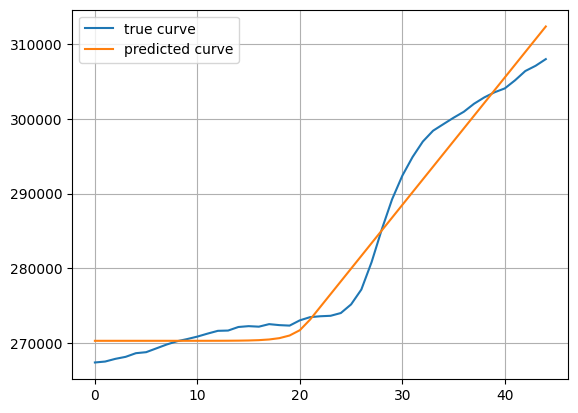

Optimization terminated successfully.
         Current function value: 2636443.109739
         Iterations: 953
         Function evaluations: 1462


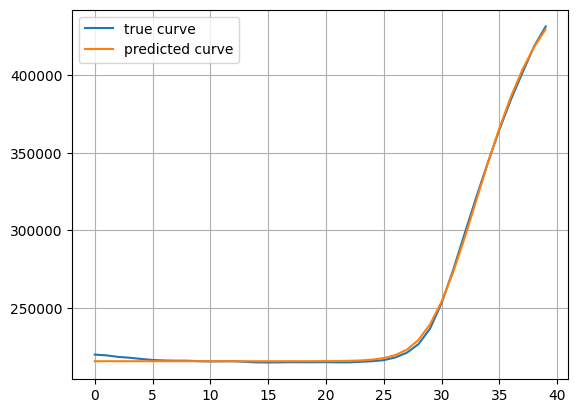

Optimization terminated successfully.
         Current function value: 20065499.116391
         Iterations: 492
         Function evaluations: 805


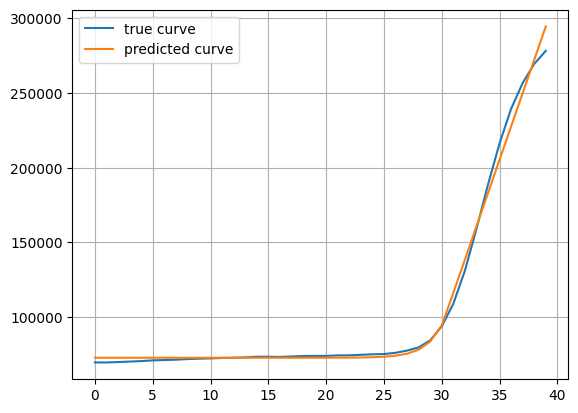

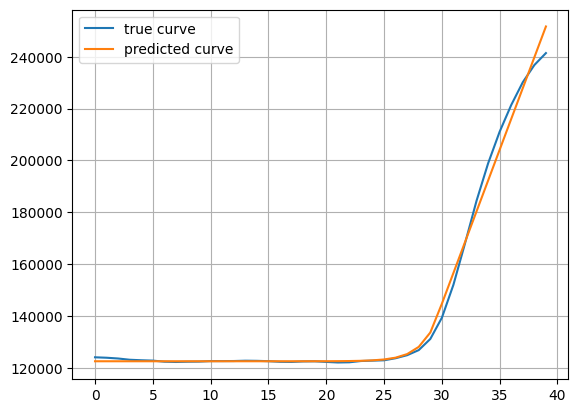

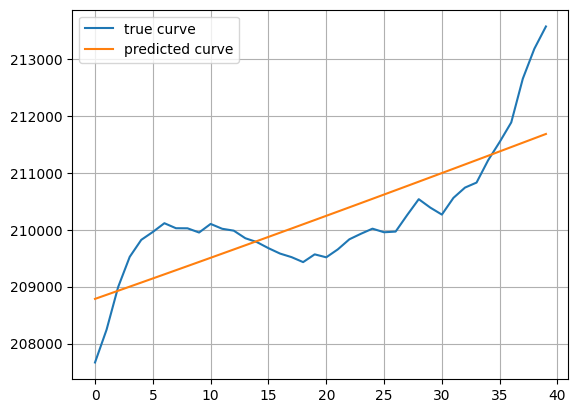

Optimization terminated successfully.
         Current function value: 419880.380136
         Iterations: 1010
         Function evaluations: 1526


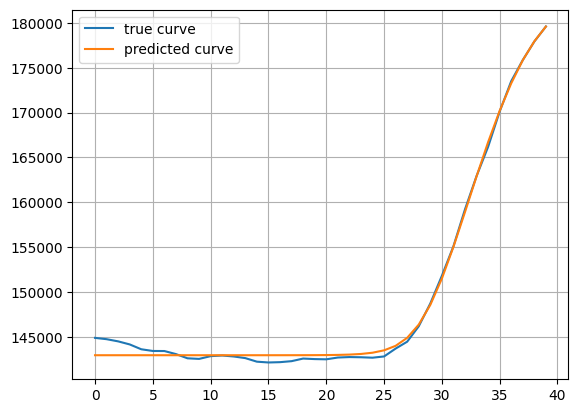

Optimization terminated successfully.
         Current function value: 1780387.903890
         Iterations: 569
         Function evaluations: 904


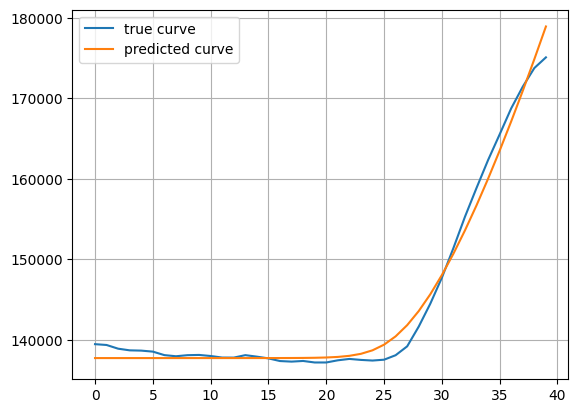

Optimization terminated successfully.
         Current function value: 14631446.134512
         Iterations: 896
         Function evaluations: 1389


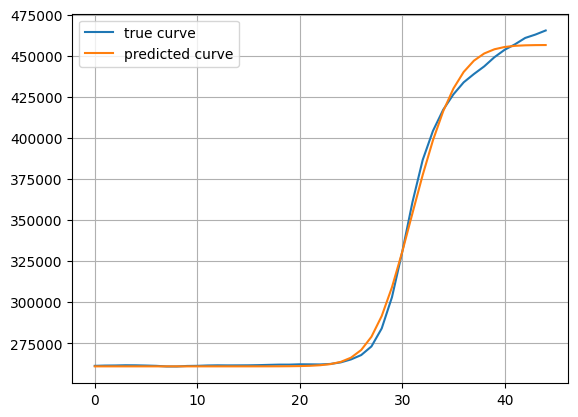

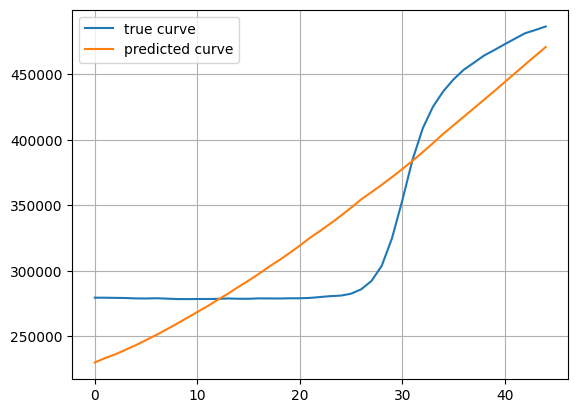

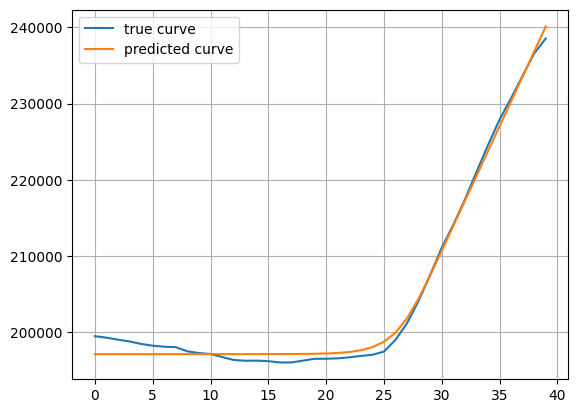

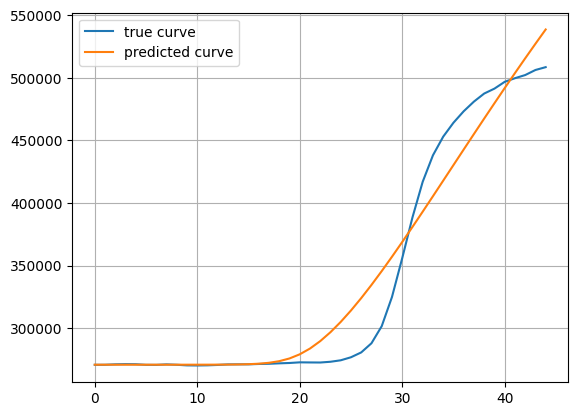

Optimization terminated successfully.
         Current function value: 189686.582666
         Iterations: 1135
         Function evaluations: 1718


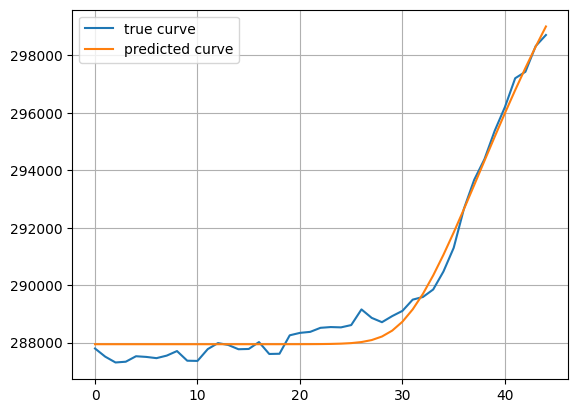

Optimization terminated successfully.
         Current function value: 49953.244467
         Iterations: 762
         Function evaluations: 1165


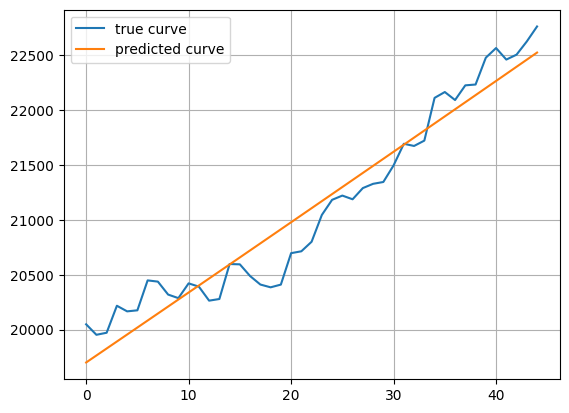

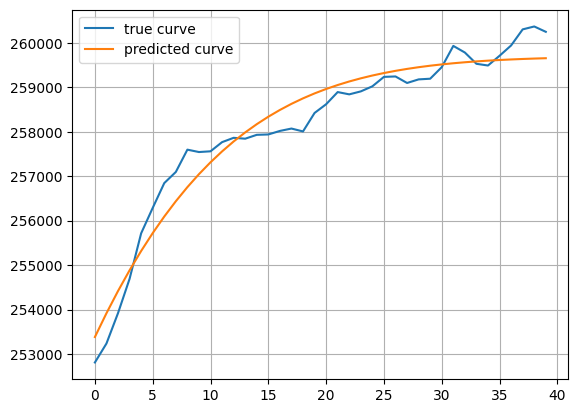

Optimization terminated successfully.
         Current function value: 3786928.868497
         Iterations: 885
         Function evaluations: 1366


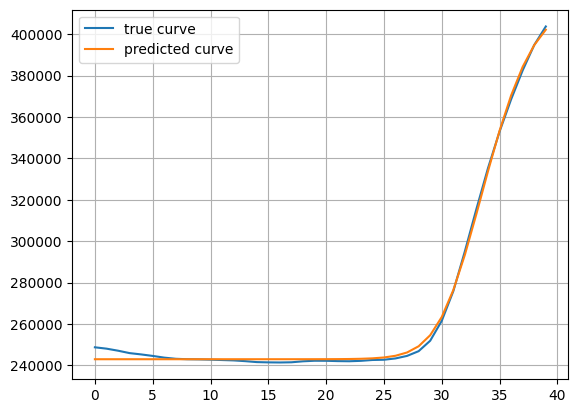

Optimization terminated successfully.
         Current function value: 5992599.349458
         Iterations: 783
         Function evaluations: 1226


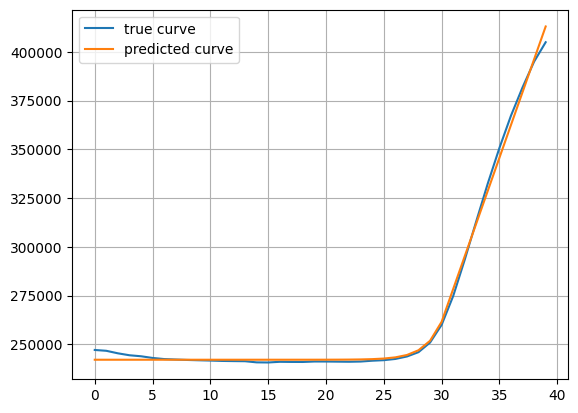

Optimization terminated successfully.
         Current function value: 60686.773617
         Iterations: 738
         Function evaluations: 1125


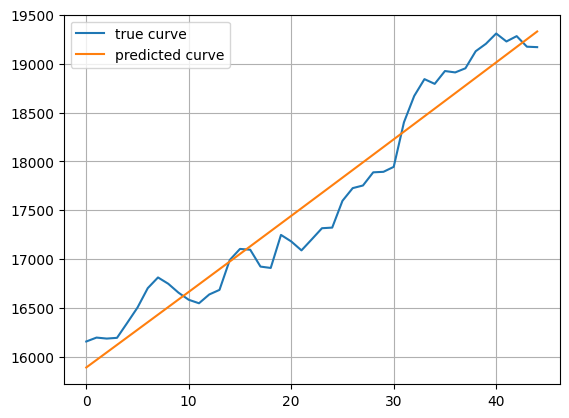

Optimization terminated successfully.
         Current function value: 9065263.658458
         Iterations: 691
         Function evaluations: 1081


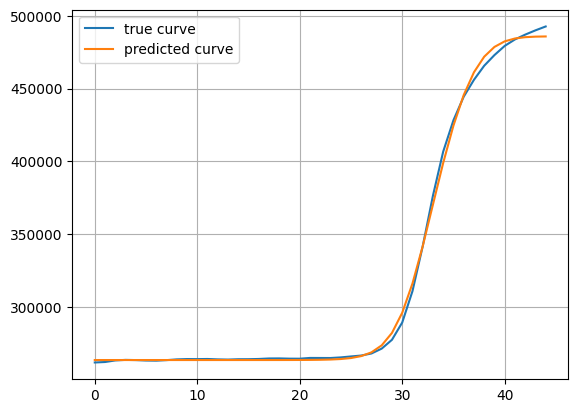

Optimization terminated successfully.
         Current function value: 98414.221169
         Iterations: 826
         Function evaluations: 1248


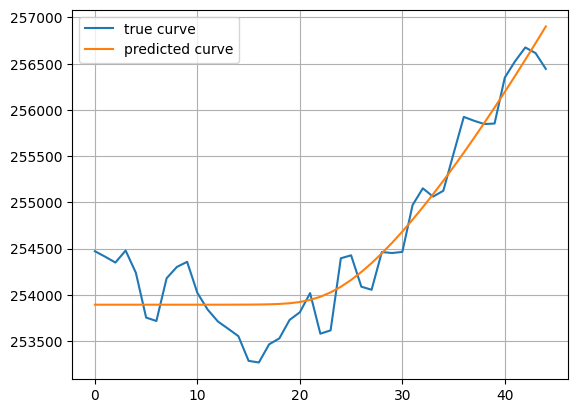

Optimization terminated successfully.
         Current function value: 41257.641025
         Iterations: 700
         Function evaluations: 1058


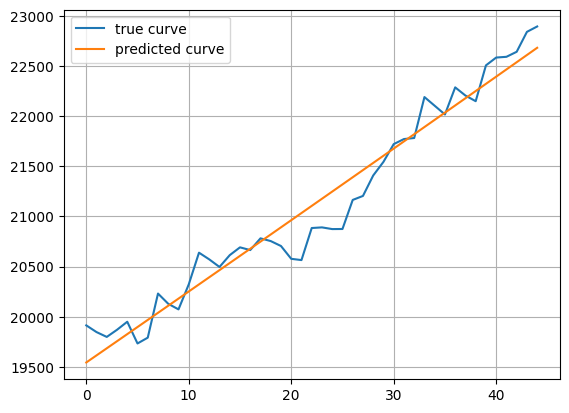

Optimization terminated successfully.
         Current function value: 14131920.081107
         Iterations: 641
         Function evaluations: 1007


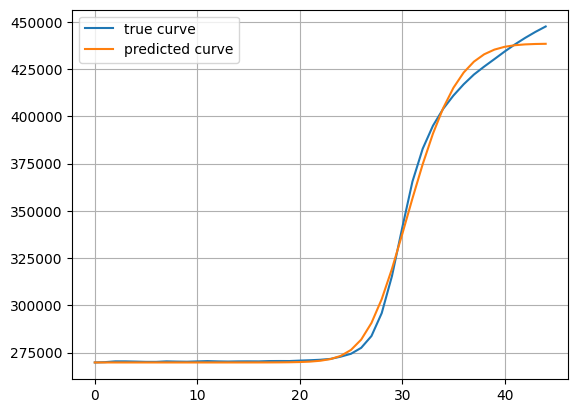

Optimization terminated successfully.
         Current function value: 85430.834292
         Iterations: 653
         Function evaluations: 981


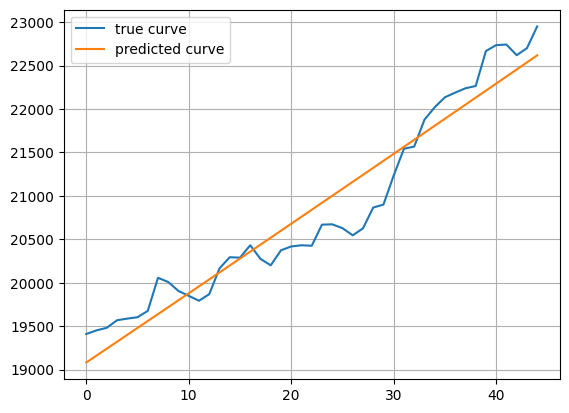

Optimization terminated successfully.
         Current function value: 36470887.315467
         Iterations: 588
         Function evaluations: 941


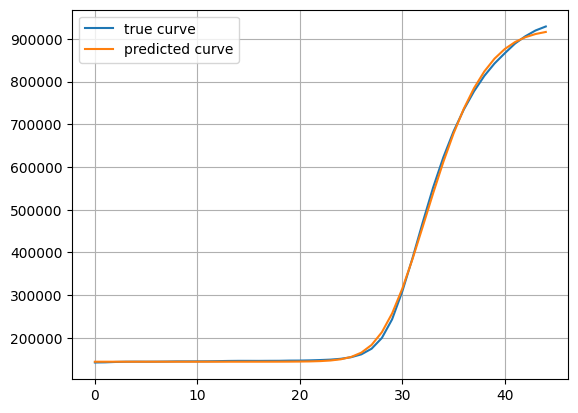

Optimization terminated successfully.
         Current function value: 10704653.393148
         Iterations: 1004
         Function evaluations: 1519


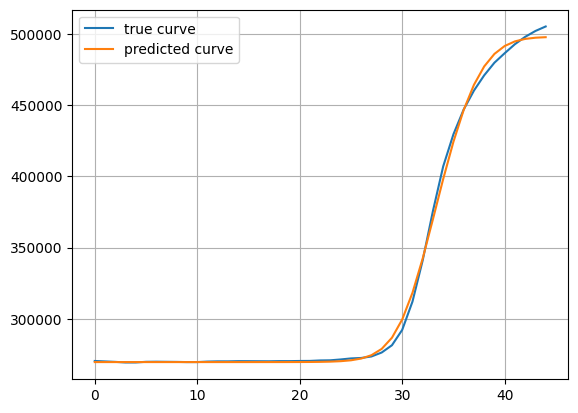

Optimization terminated successfully.
         Current function value: 55768574.134626
         Iterations: 737
         Function evaluations: 1142


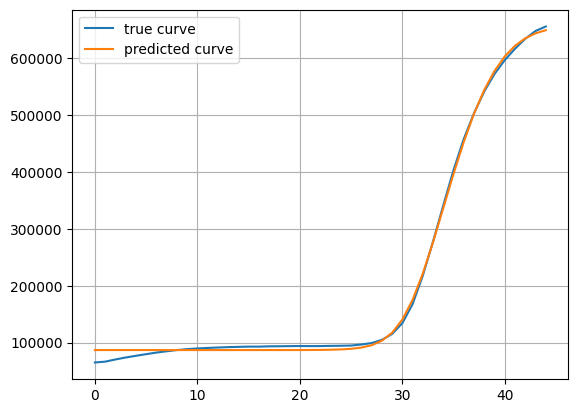

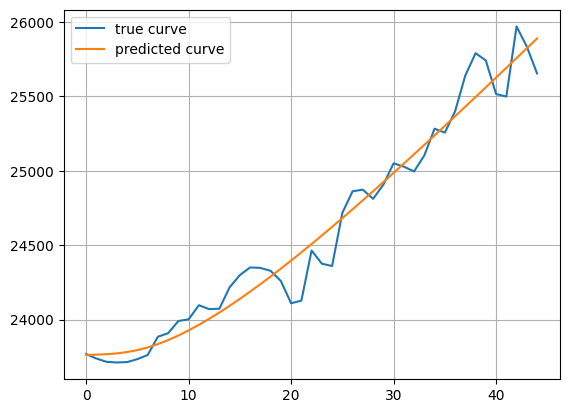

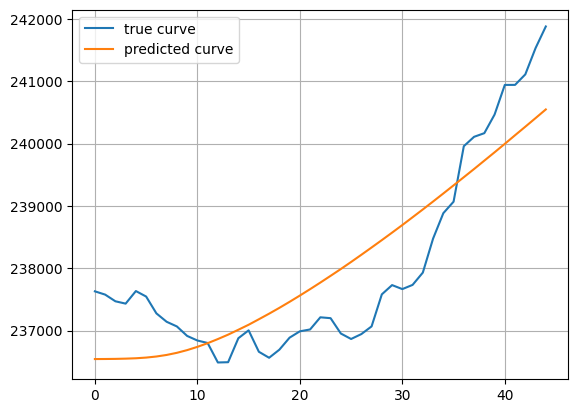

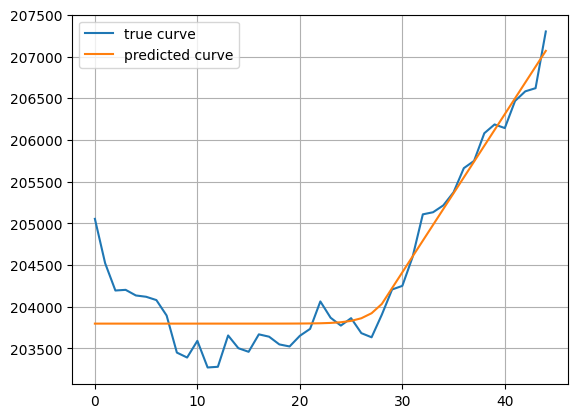

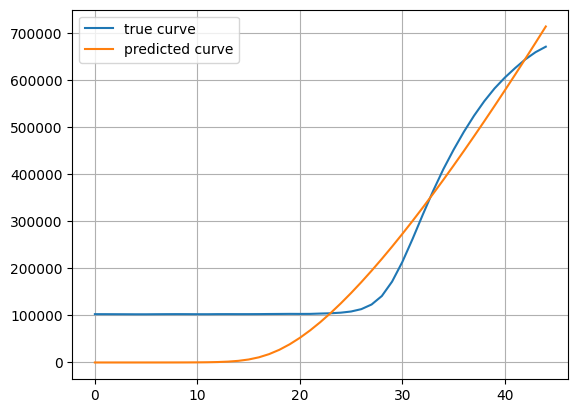

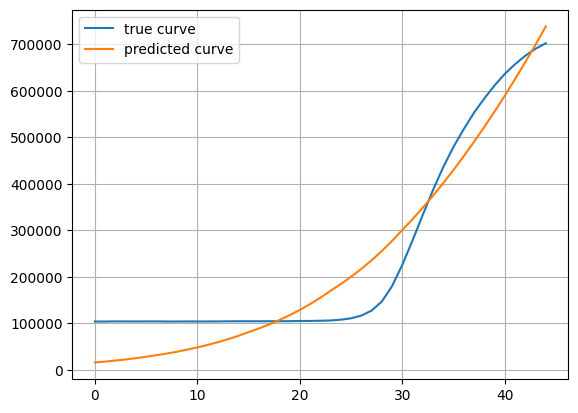

Optimization terminated successfully.
         Current function value: 6078167547.948865
         Iterations: 1003
         Function evaluations: 1769


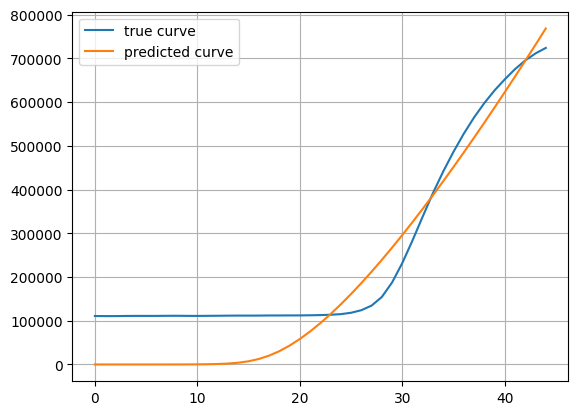

Optimization terminated successfully.
         Current function value: 1503231.455224
         Iterations: 695
         Function evaluations: 1094


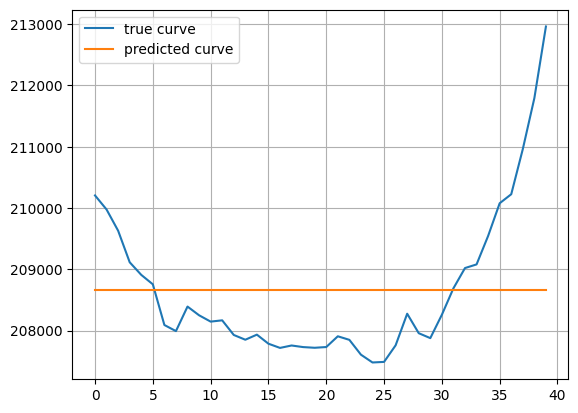

Optimization terminated successfully.
         Current function value: 38566.195840
         Iterations: 729
         Function evaluations: 1108


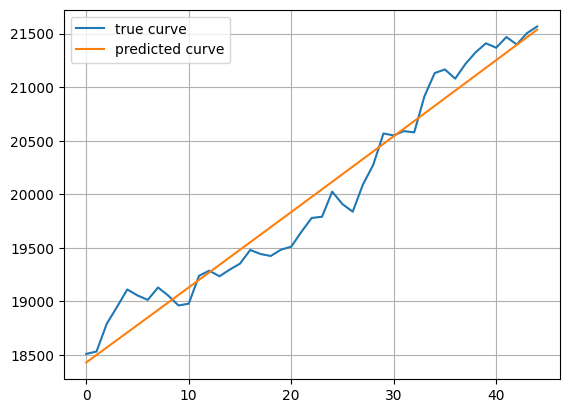

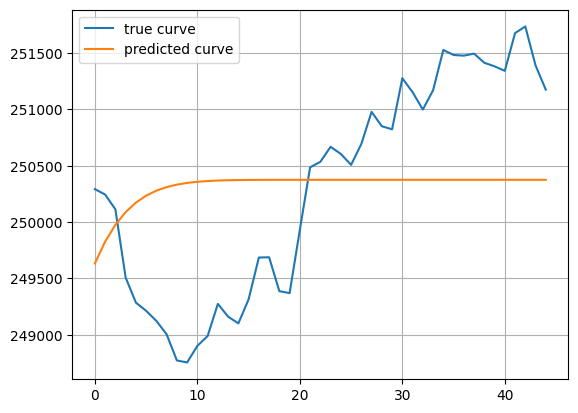

Optimization terminated successfully.
         Current function value: 45537186.352441
         Iterations: 507
         Function evaluations: 783


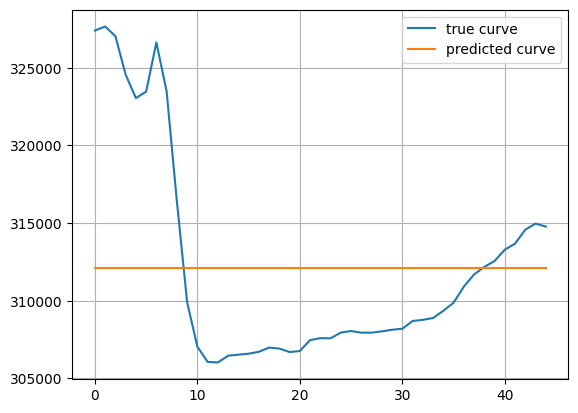

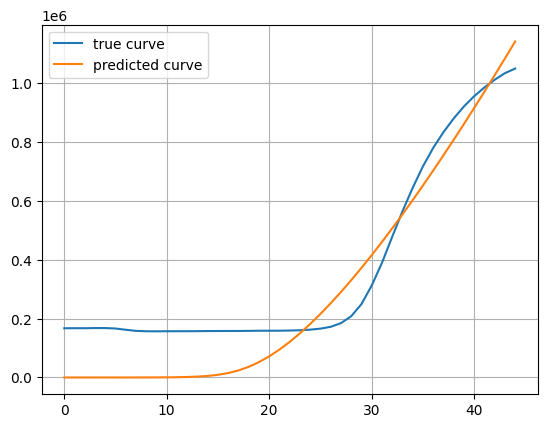

Optimization terminated successfully.
         Current function value: 42453436.656067
         Iterations: 753
         Function evaluations: 1179


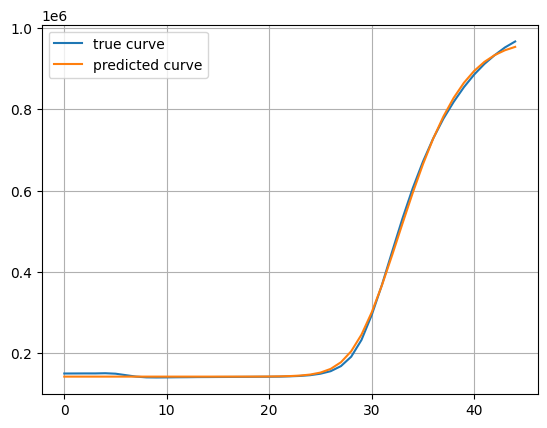

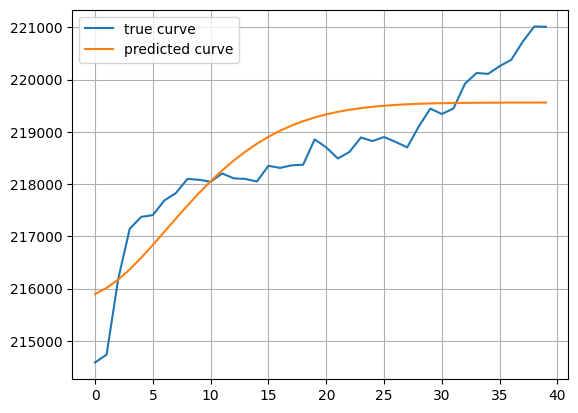

Optimization terminated successfully.
         Current function value: 3555937.196776
         Iterations: 521
         Function evaluations: 835


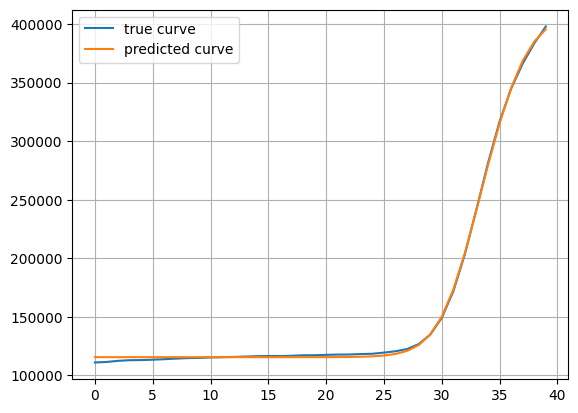

Optimization terminated successfully.
         Current function value: 14128149.336548
         Iterations: 1011
         Function evaluations: 1510


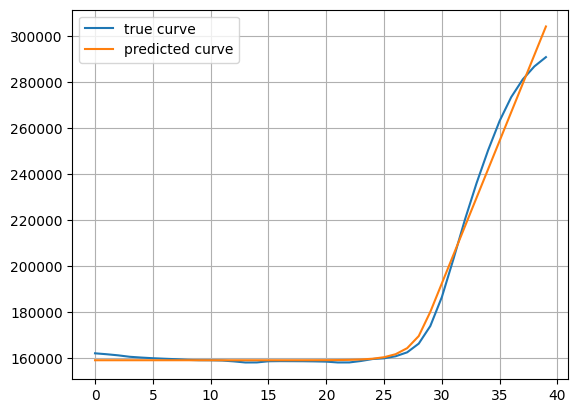

Optimization terminated successfully.
         Current function value: 2183186.063323
         Iterations: 757
         Function evaluations: 1141


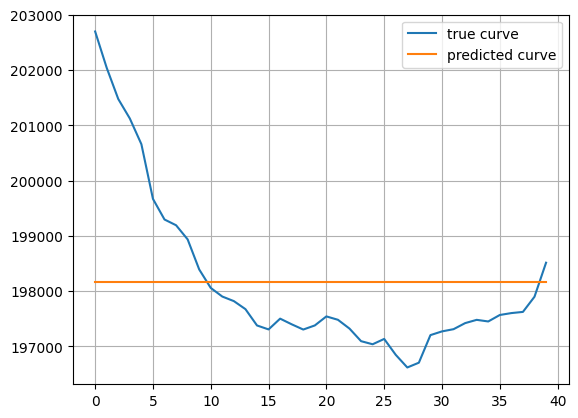

Optimization terminated successfully.
         Current function value: 1675417.183786
         Iterations: 412
         Function evaluations: 655


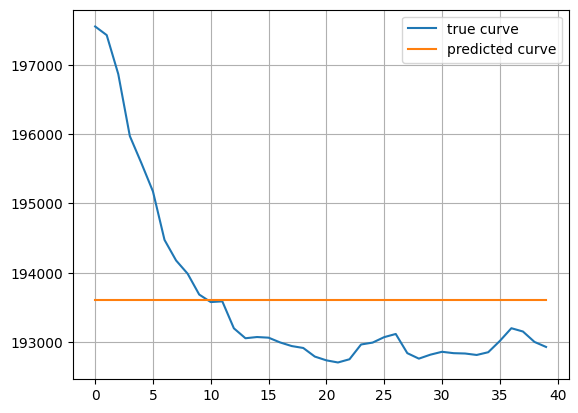

Optimization terminated successfully.
         Current function value: 6724477.995116
         Iterations: 554
         Function evaluations: 877


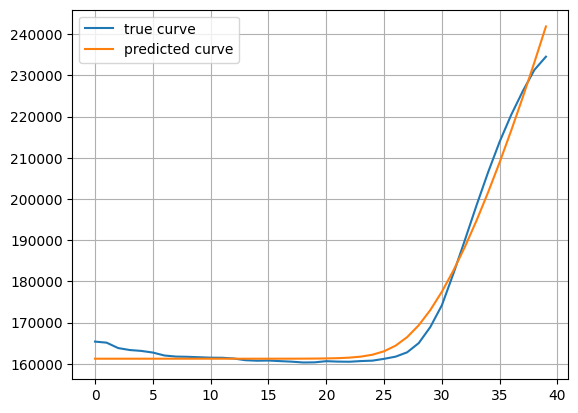

Optimization terminated successfully.
         Current function value: 1765988.781895
         Iterations: 763
         Function evaluations: 1195


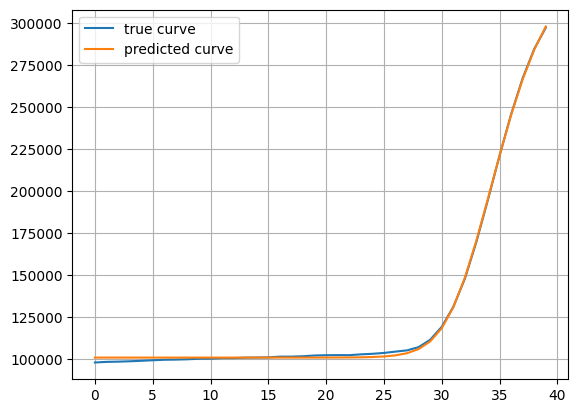

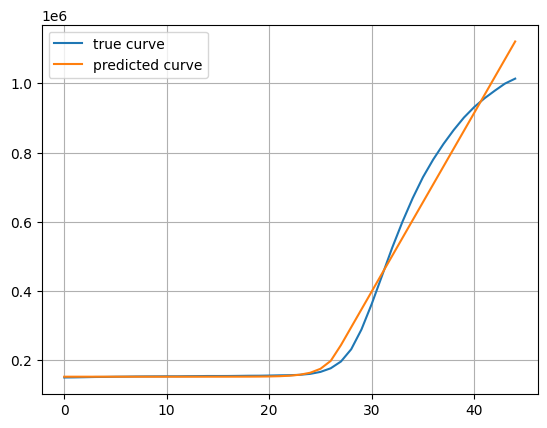

Optimization terminated successfully.
         Current function value: 2390888.069575
         Iterations: 1084
         Function evaluations: 1656


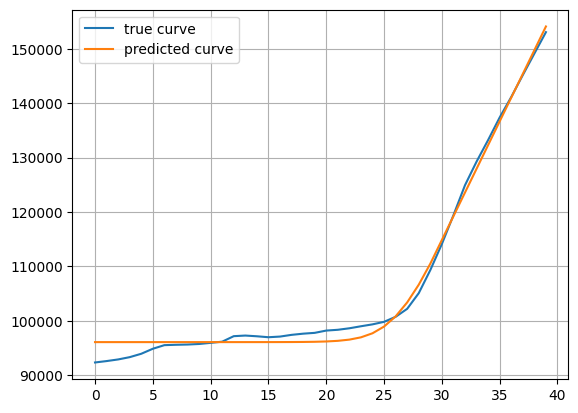

Optimization terminated successfully.
         Current function value: 20094734.470027
         Iterations: 566
         Function evaluations: 885


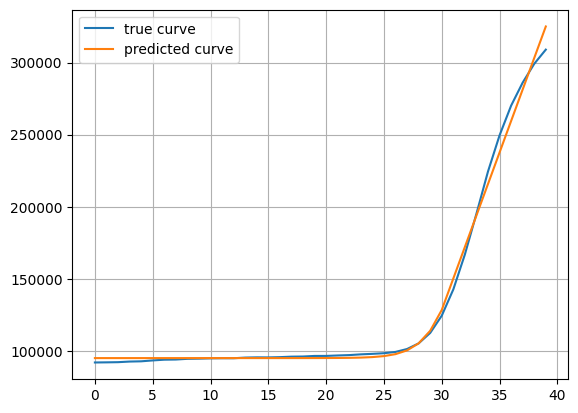

Optimization terminated successfully.
         Current function value: 111541.076317
         Iterations: 580
         Function evaluations: 900


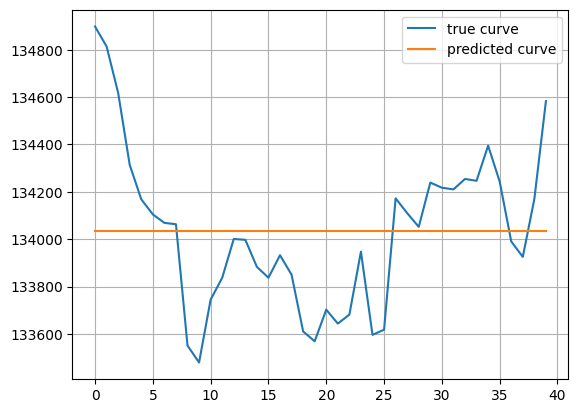

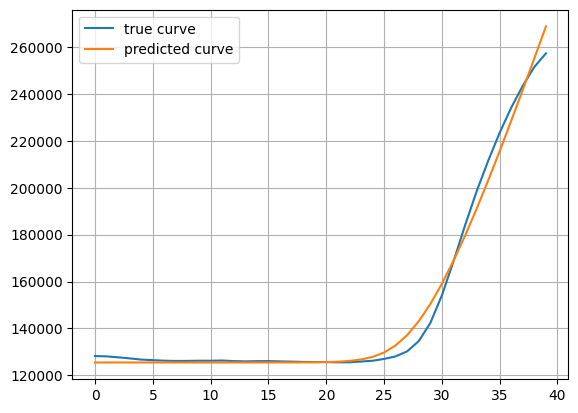

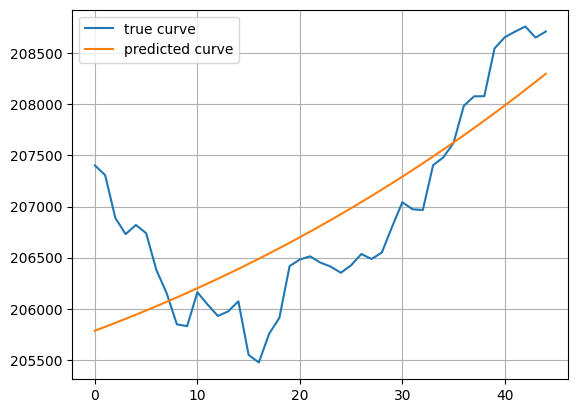

Optimization terminated successfully.
         Current function value: 95795.856704
         Iterations: 928
         Function evaluations: 1400


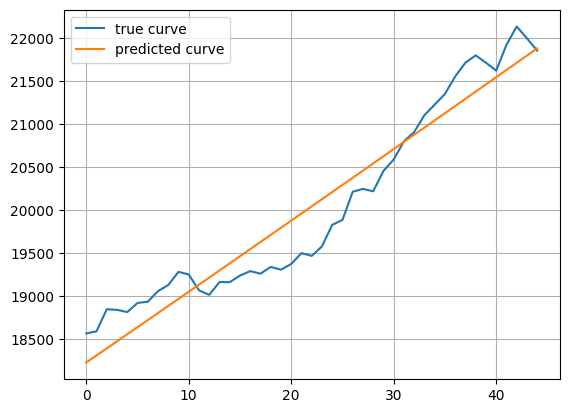

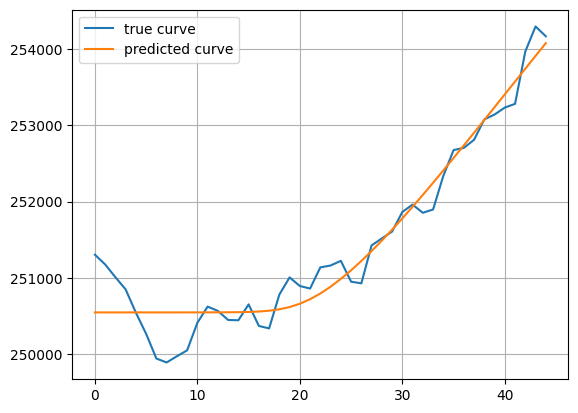

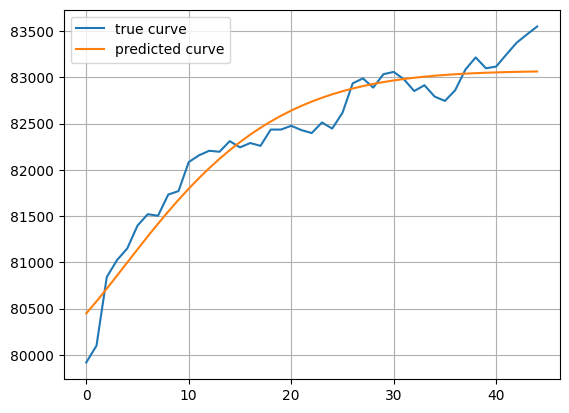

Optimization terminated successfully.
         Current function value: 67195.187205
         Iterations: 774
         Function evaluations: 1178


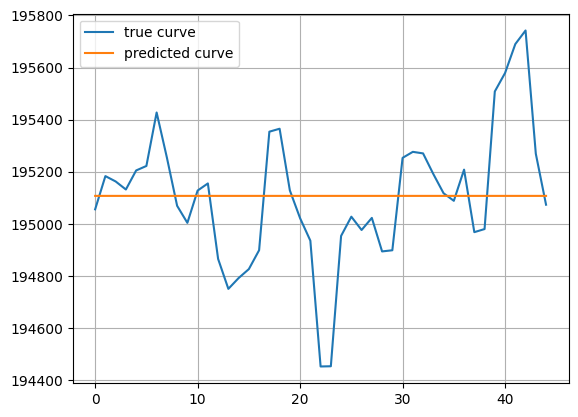

Optimization terminated successfully.
         Current function value: 128518100.661293
         Iterations: 985
         Function evaluations: 1480


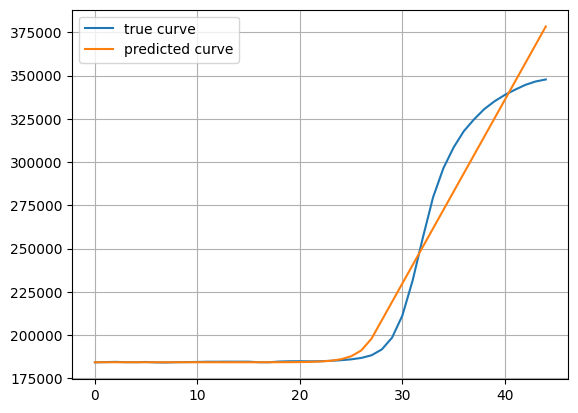

Optimization terminated successfully.
         Current function value: 10157907.769111
         Iterations: 800
         Function evaluations: 1221


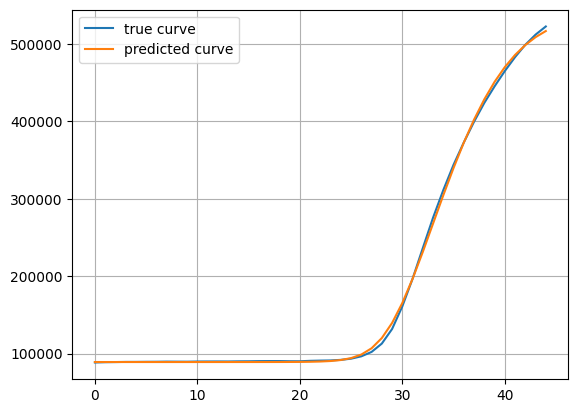

Optimization terminated successfully.
         Current function value: 10571805.361439
         Iterations: 799
         Function evaluations: 1234


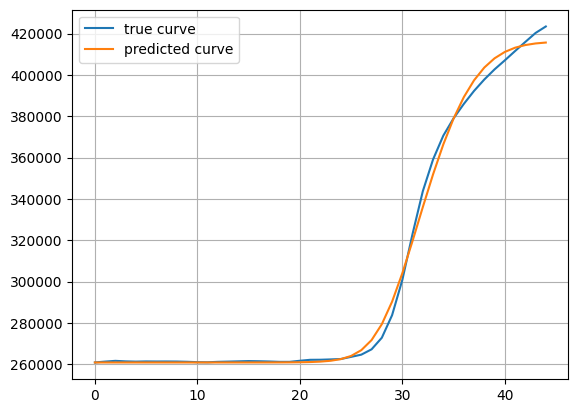

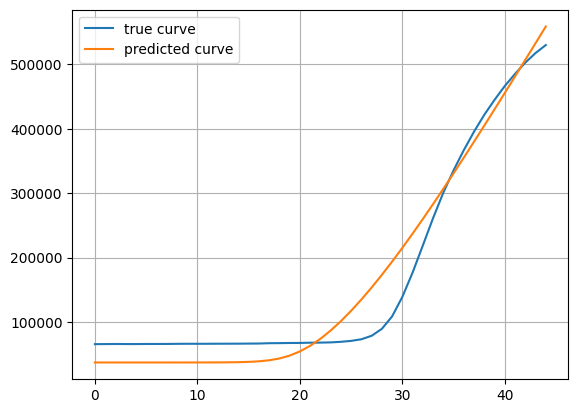

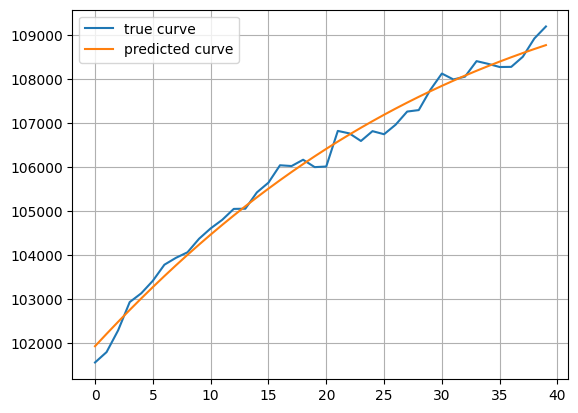

Optimization terminated successfully.
         Current function value: 26442.047426
         Iterations: 889
         Function evaluations: 1352


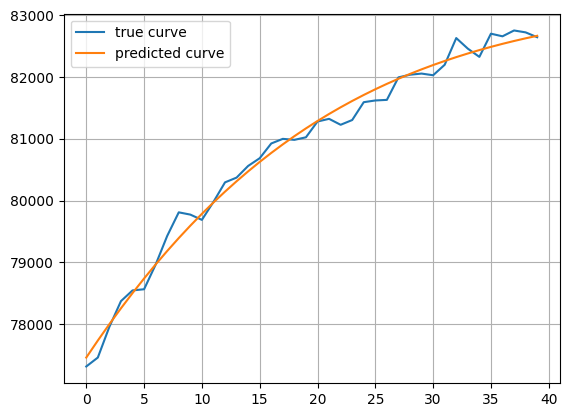

Optimization terminated successfully.
         Current function value: 814345.116705
         Iterations: 833
         Function evaluations: 1280


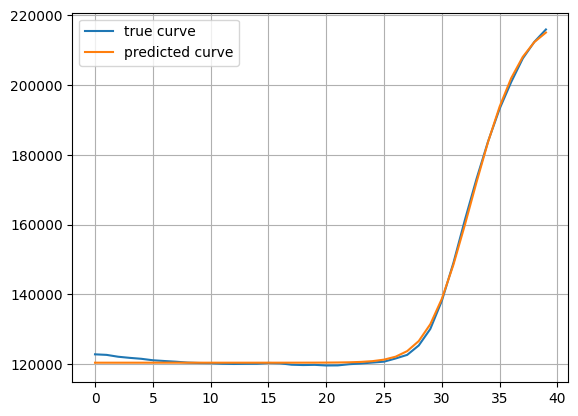

Optimization terminated successfully.
         Current function value: 594561.666290
         Iterations: 599
         Function evaluations: 937


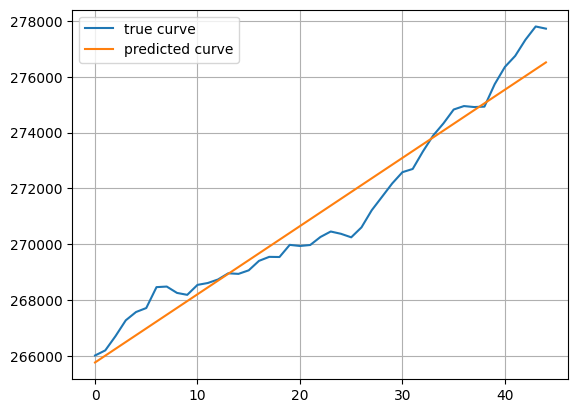

Optimization terminated successfully.
         Current function value: 82740.441137
         Iterations: 520
         Function evaluations: 822


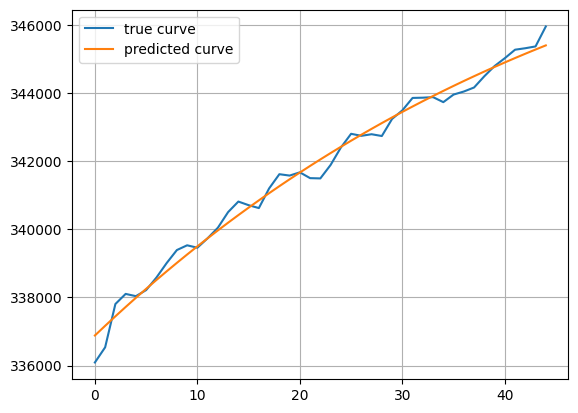

Optimization terminated successfully.
         Current function value: 531544.069998
         Iterations: 729
         Function evaluations: 1137


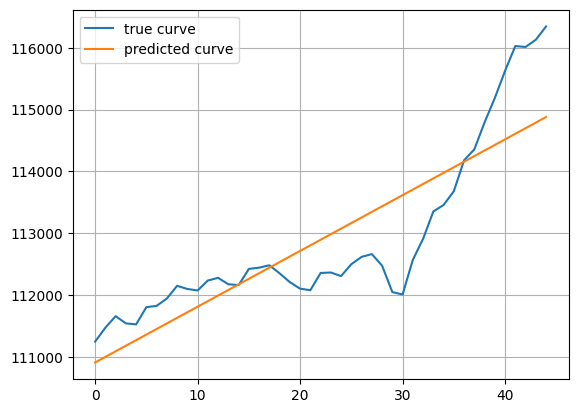

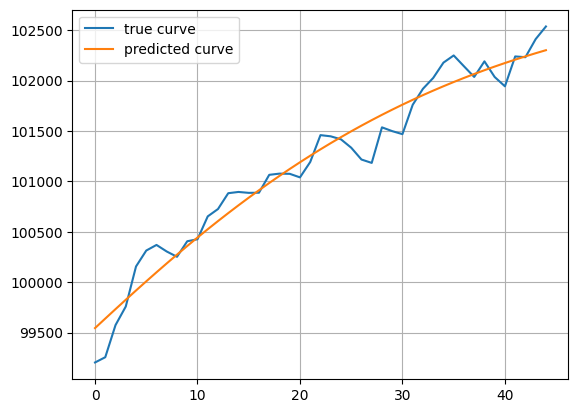

Optimization terminated successfully.
         Current function value: 4289436.618366
         Iterations: 774
         Function evaluations: 1196


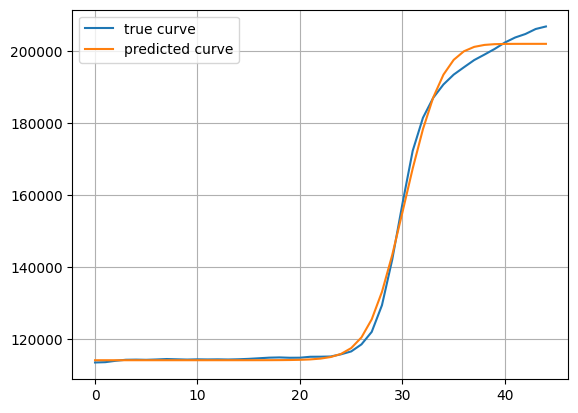

Optimization terminated successfully.
         Current function value: 15064621.475597
         Iterations: 796
         Function evaluations: 1241


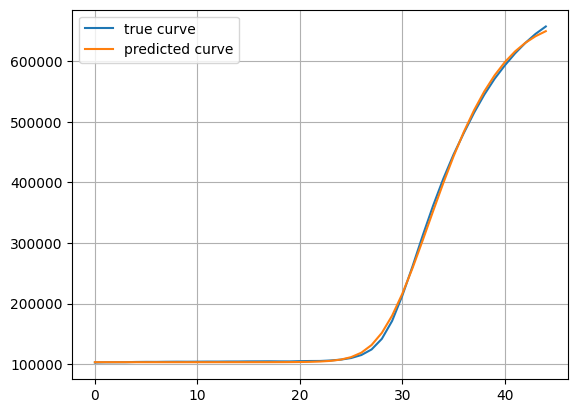

Optimization terminated successfully.
         Current function value: 9949718.954213
         Iterations: 661
         Function evaluations: 1035


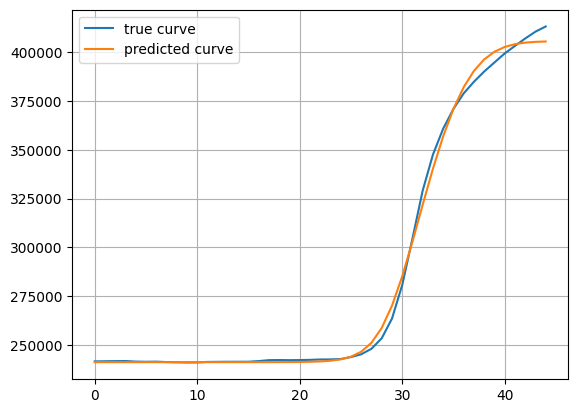

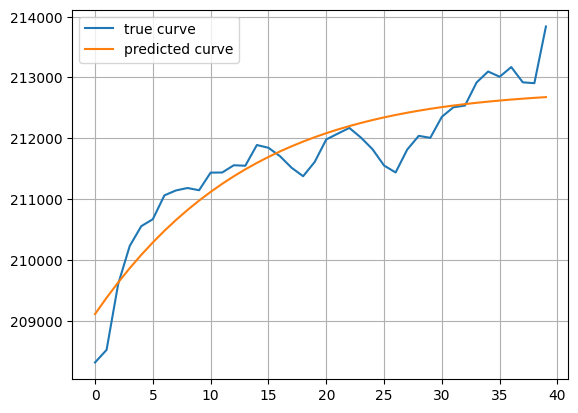

Optimization terminated successfully.
         Current function value: 3974269.967874
         Iterations: 544
         Function evaluations: 868


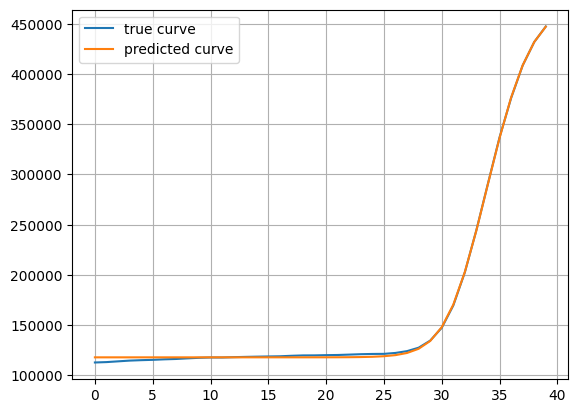

Optimization terminated successfully.
         Current function value: 25086.661645
         Iterations: 444
         Function evaluations: 701


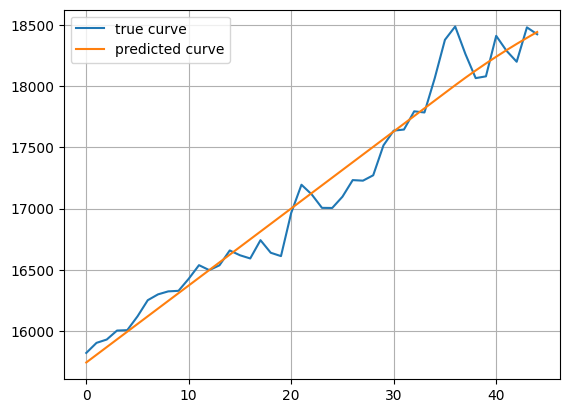

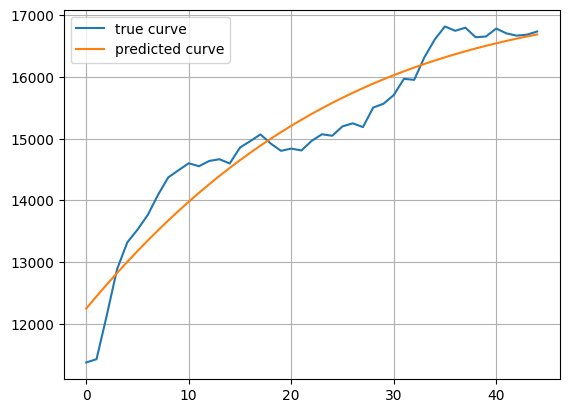

Optimization terminated successfully.
         Current function value: 146792843.282024
         Iterations: 585
         Function evaluations: 948


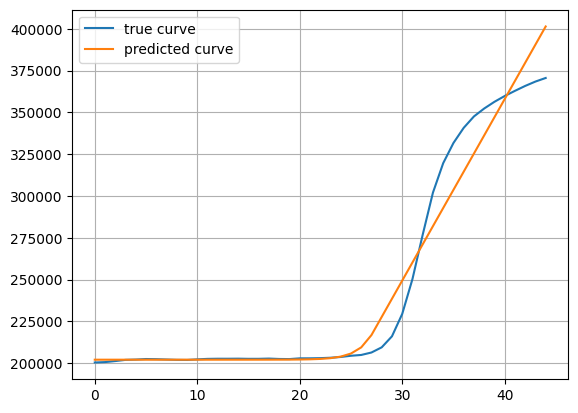

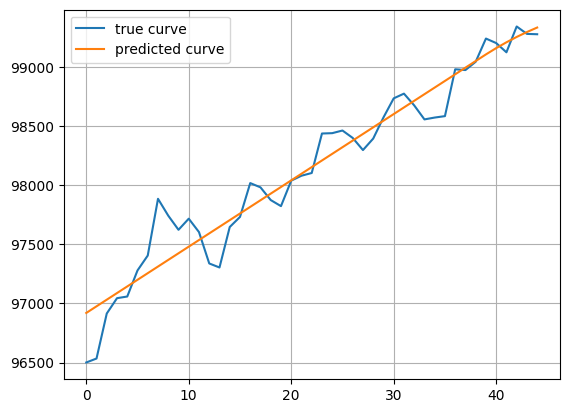

Optimization terminated successfully.
         Current function value: 4784454.073916
         Iterations: 424
         Function evaluations: 679


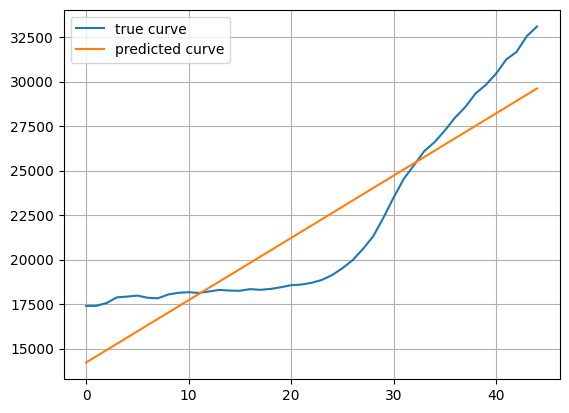

Optimization terminated successfully.
         Current function value: 676151572.249680
         Iterations: 421
         Function evaluations: 704


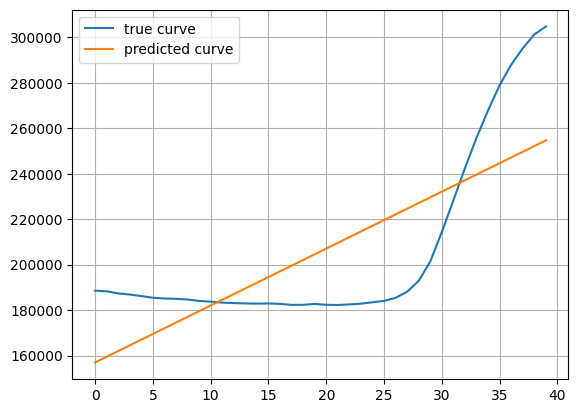

Optimization terminated successfully.
         Current function value: 8644955.407065
         Iterations: 1172
         Function evaluations: 1759


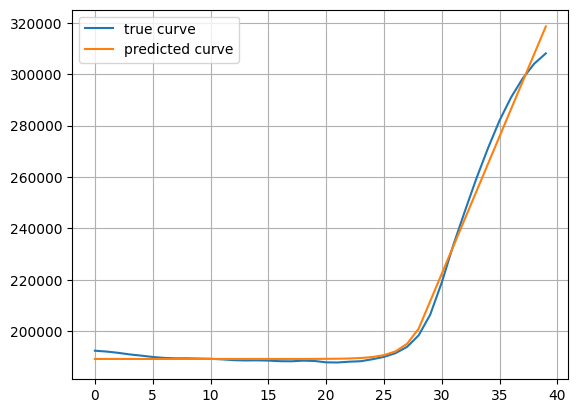

Optimization terminated successfully.
         Current function value: 1881296.697628
         Iterations: 839
         Function evaluations: 1283


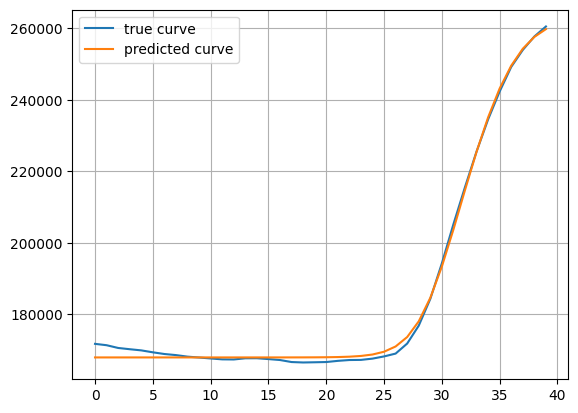

Optimization terminated successfully.
         Current function value: 3545930880.330253
         Iterations: 654
         Function evaluations: 997


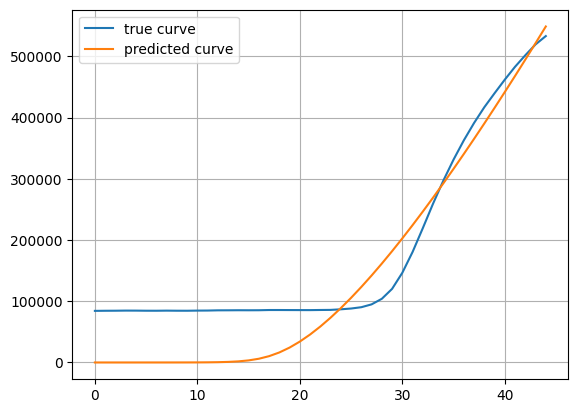

Optimization terminated successfully.
         Current function value: 18996326.219423
         Iterations: 650
         Function evaluations: 1007


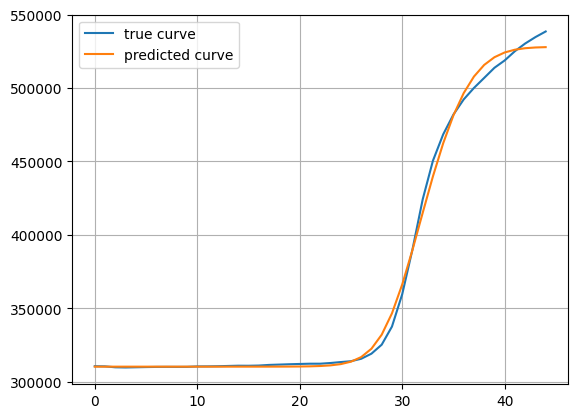

Optimization terminated successfully.
         Current function value: 99238.377314
         Iterations: 1005
         Function evaluations: 1541


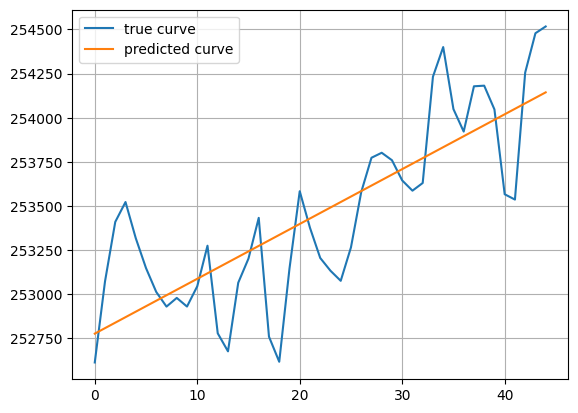

Optimization terminated successfully.
         Current function value: 33554.083763
         Iterations: 1003
         Function evaluations: 1509


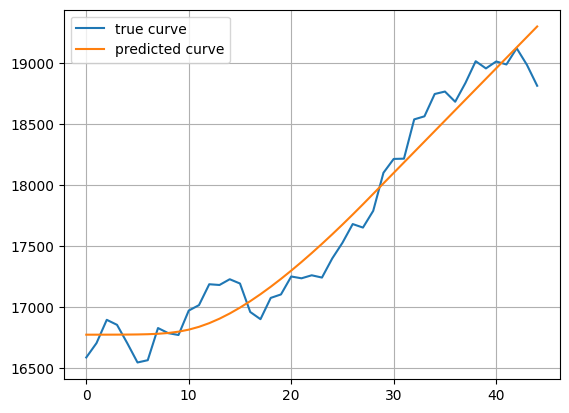

Optimization terminated successfully.
         Current function value: 659158945.363316
         Iterations: 1126
         Function evaluations: 1677


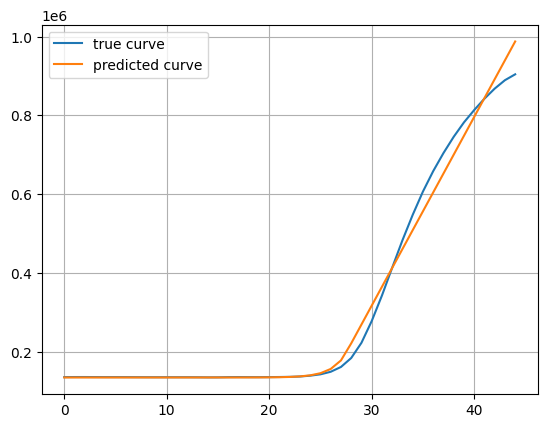

Optimization terminated successfully.
         Current function value: 7256.395974
         Iterations: 818
         Function evaluations: 1277


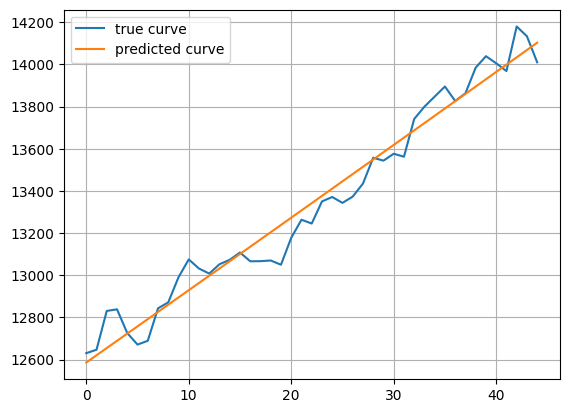

Optimization terminated successfully.
         Current function value: 13045731.211378
         Iterations: 717
         Function evaluations: 1100


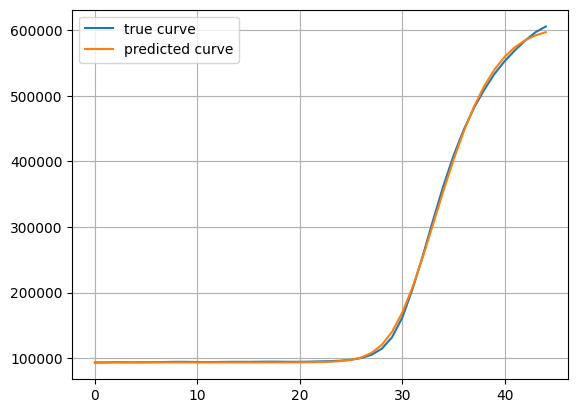

Optimization terminated successfully.
         Current function value: 11112703.208906
         Iterations: 671
         Function evaluations: 1060


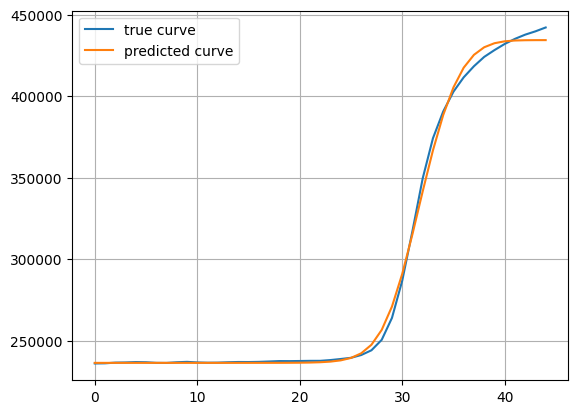

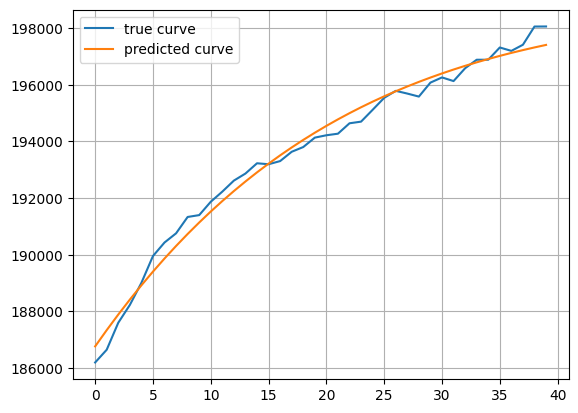

Optimization terminated successfully.
         Current function value: 1344688.428570
         Iterations: 751
         Function evaluations: 1167


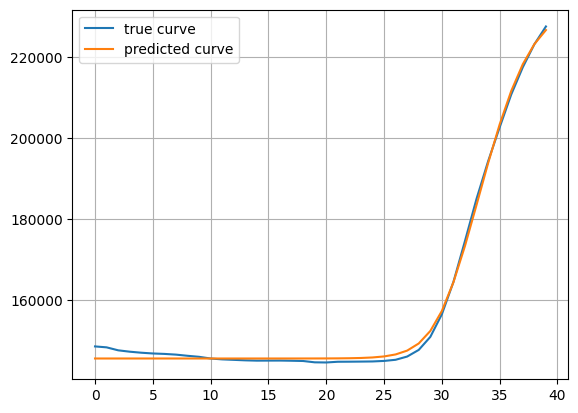

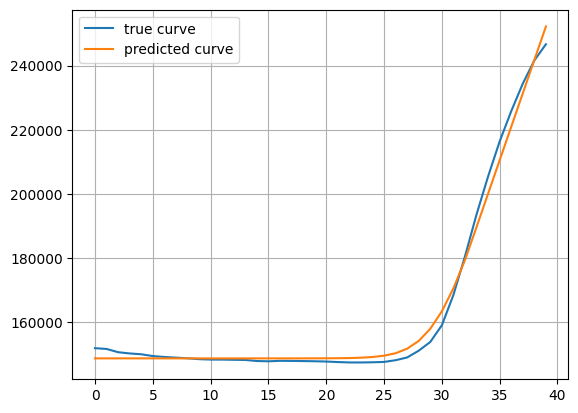

Optimization terminated successfully.
         Current function value: 83186.032854
         Iterations: 846
         Function evaluations: 1302


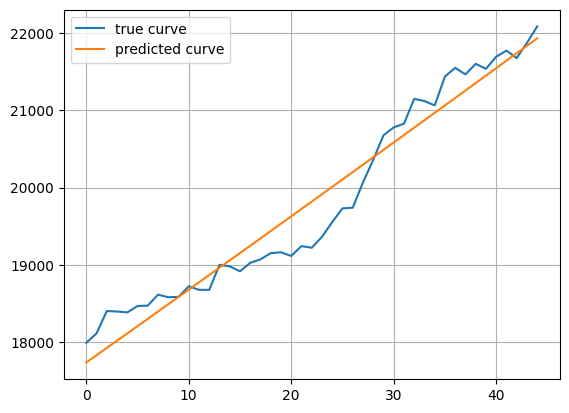

Optimization terminated successfully.
         Current function value: 47817.828749
         Iterations: 539
         Function evaluations: 855


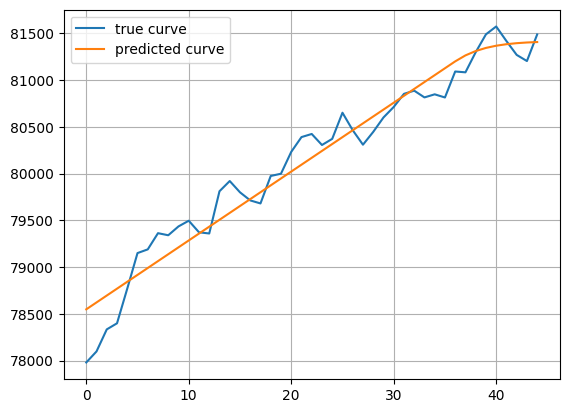

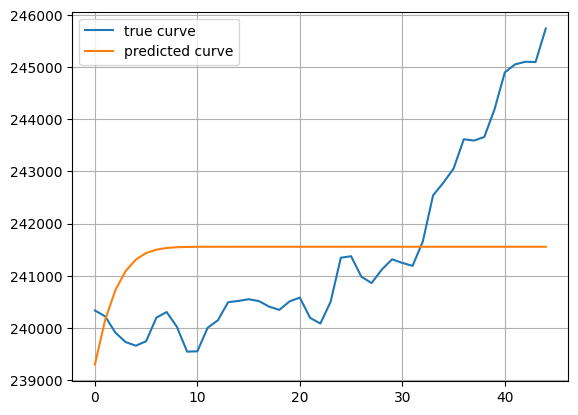

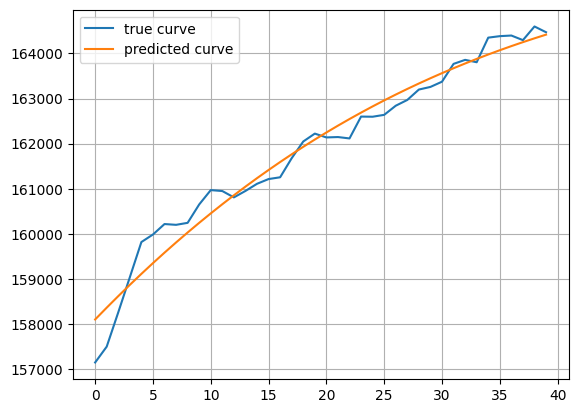

Optimization terminated successfully.
         Current function value: 963975.426200
         Iterations: 608
         Function evaluations: 934


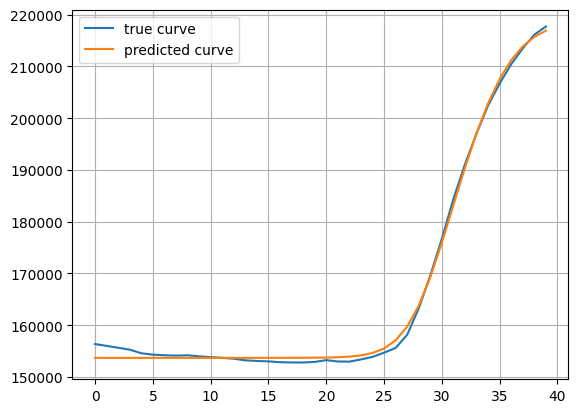

Optimization terminated successfully.
         Current function value: 1101392.572843
         Iterations: 522
         Function evaluations: 850


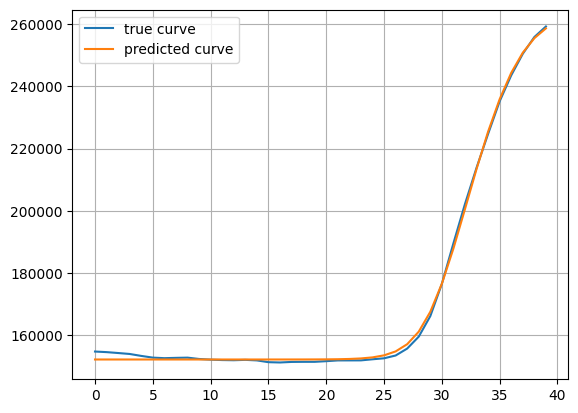

Optimization terminated successfully.
         Current function value: 6083827.837865
         Iterations: 1133
         Function evaluations: 1673


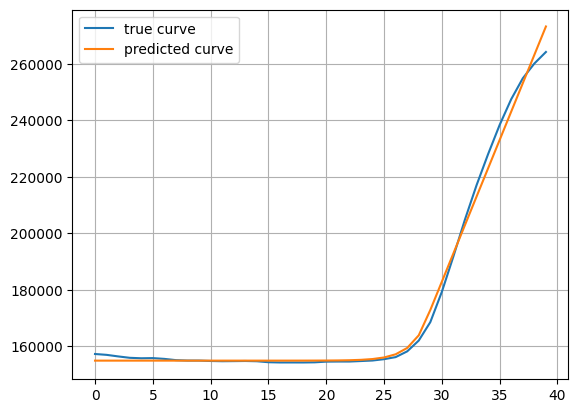

Optimization terminated successfully.
         Current function value: 15222977.573995
         Iterations: 714
         Function evaluations: 1117


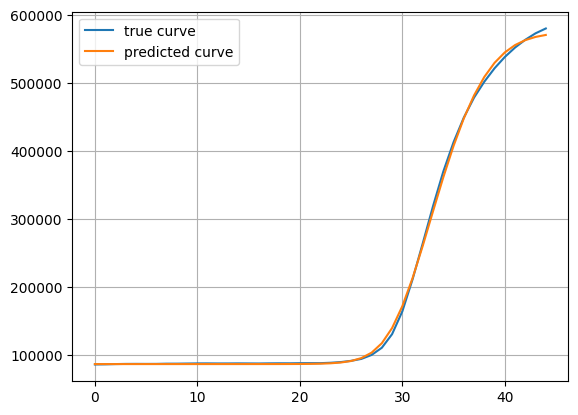

Optimization terminated successfully.
         Current function value: 8008922.228173
         Iterations: 792
         Function evaluations: 1231


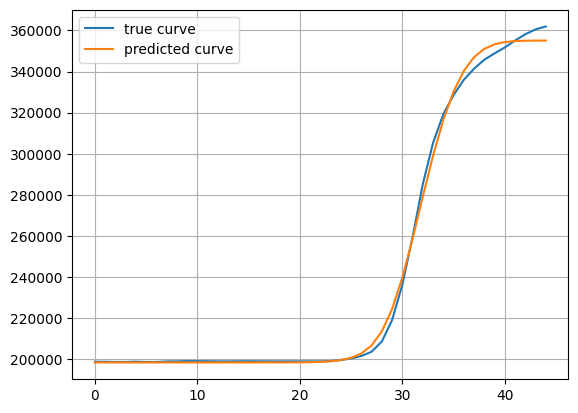

Optimization terminated successfully.
         Current function value: 73564.022869
         Iterations: 487
         Function evaluations: 794


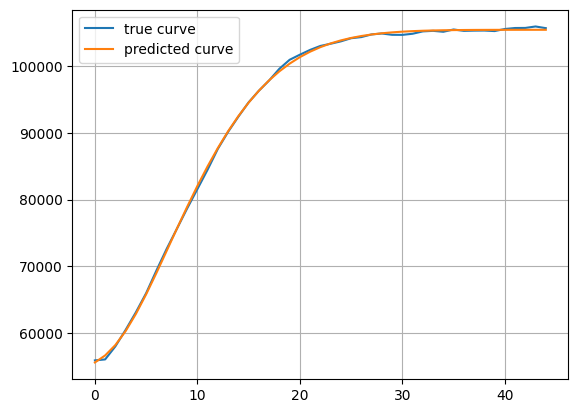

Optimization terminated successfully.
         Current function value: 440181.492731
         Iterations: 754
         Function evaluations: 1516


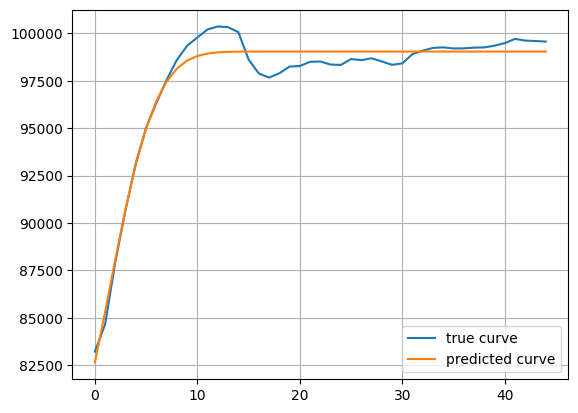

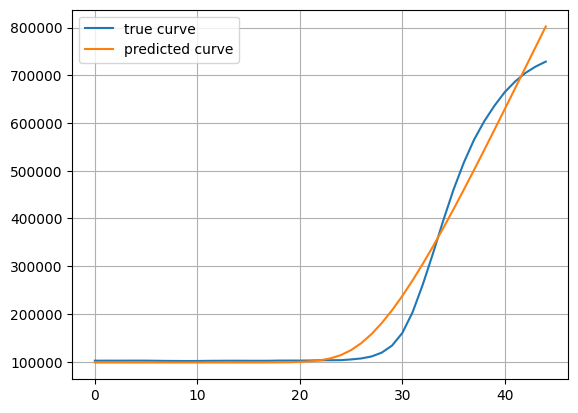

Optimization terminated successfully.
         Current function value: 1102752.994460
         Iterations: 865
         Function evaluations: 1321


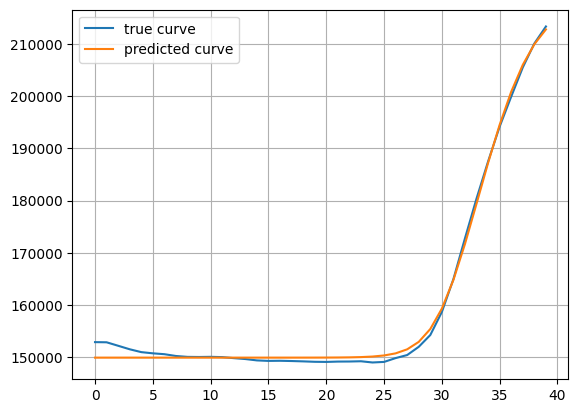

Optimization terminated successfully.
         Current function value: 227879.112815
         Iterations: 795
         Function evaluations: 1203


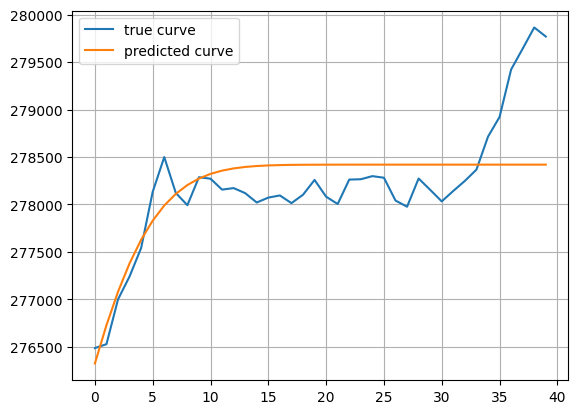

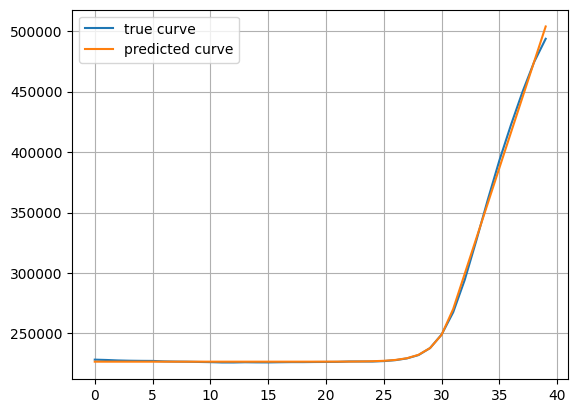

Optimization terminated successfully.
         Current function value: 132407.521731
         Iterations: 446
         Function evaluations: 715


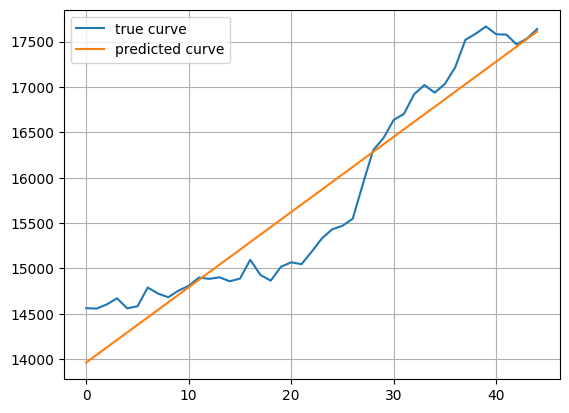

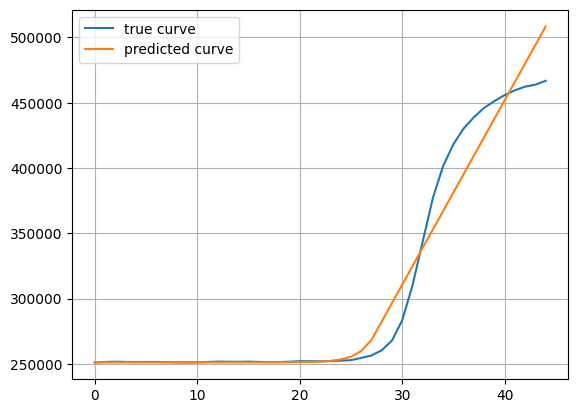

Optimization terminated successfully.
         Current function value: 15296859.537758
         Iterations: 551
         Function evaluations: 891


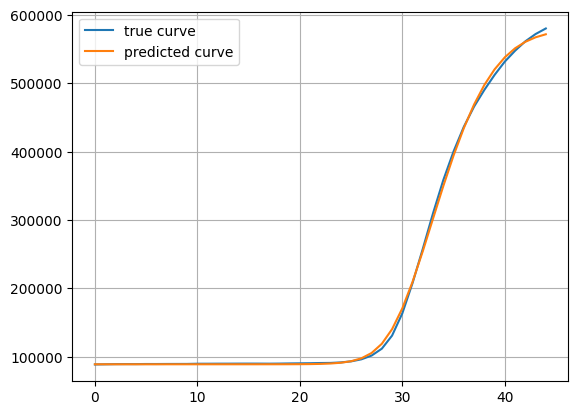

In [36]:
for index, row in ground_truth_targets.iterrows():
    
    #get curve corresponding to row
    curve = curve_dict[row['curve_idx']]
    # print(len(curve))
    
    # print(int(len(curve)))
    
    n_cycle = int(len(curve)) - 1

    # plt.plot(curve)
    
    #instantiate
    init_params = np.array([4, 6, 5, 5, 1, 0, 0, 1, 1])
    
    #perform optimization
    res = minimize(func_to_optimize, init_params, method='nelder-mead', options={'xatol': 1e-1, 'disp': True})
    
    #get the predicted curve
    D_e_pred = simulate_vals(D_init=Decimal(10**res.x[0]),
                    E_init=Decimal(10**res.x[1]), 
                    P_init=Decimal(10**res.x[2]), 
                    delta_e=Decimal(10**res.x[4]),
                    n_d=Decimal(10**0),
                    n_dE=Decimal(10**0),
                    k_C=Decimal(10**res.x[7]),
                    beta=Decimal(10**res.x[8]),
                    n_cycle=n_cycle)[2]

    D_e_pred = np.array([float(str(x)) + 10**res.x[3] for x in D_e_pred])
    
    mse = ((curve - D_e_pred)**2).mean()
    #calculate mse relative to real curve

    plt.plot(curve, label = 'true curve')
    plt.plot(D_e_pred, label = 'predicted curve')
    plt.legend()
    plt.grid()
    plt.show()

    
    
    
    